# Прогнозирование месячного пассажиропотока (заполненность поездов)

Датасет: [Train Occupancy Time Series](https://www.kaggle.com/datasets/gajjadarahul/predict-train-occupancy-time-series) (взял с kaggle)

Задача: Прогноз на горизонт 24 месяца  

In [1]:
# Базовые импорты
import warnings
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Python:', sys.version)
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('ROOT:', ROOT)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Pandas: 2.3.3
NumPy: 1.26.4
ROOT: C:\Projects\project


## ЗАДАЧА 1

1.1 Загрузка и первичный анализ данных

Датасет содержит информацию о заполняемости вагонов поездов (occupancy).  
Исходные данные могут иметь частоту выше месячной - в таком случае мы агрегируем до месячного уровня.

Логика агрегации: суммируем показатель occupancy по всем записям внутри каждого месяца,  
получая суммарный пассажиропоток за месяц. Это стандартная практика для транспортных данных.

In [2]:
from src.data_preparation import (
    load_raw_data, quality_report,
    detect_datetime_column, detect_target_column,
    clean_data, aggregate_to_monthly, prepare_data
)

# ---- Укажите путь к скачанному CSV ----
RAW_CSV = '../data/raw/train_occupancy.csv'
raw_df = load_raw_data(RAW_CSV)
print('Форма данных:', raw_df.shape)
raw_df.head()

2026-06-09 18:10:17,921 INFO Загрузка данных из ..\data\raw\train_occupancy.csv
2026-06-09 18:10:17,933 INFO Загружено строк: 150, колонок: 3
2026-06-09 18:10:17,934 INFO Колонки: ['Unnamed: 0', 'Time', 'Total Occupancy rate (percent)']


Форма данных: (150, 3)


,Unnamed: 0,Time,Total Occupancy rate (percent)
0,0,1999M01,43.7
1,1,1999M02,41.0
2,2,1999M03,36.5
3,3,1999M04,32.8
4,4,1999M05,24.5


In [3]:
# Типы данных
print('Типы данных:')
print(raw_df.dtypes)

# Пропуски
print('\nПропуски:')
missing = raw_df.isnull().sum()
pct = (raw_df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': pct})
print(missing_df[missing_df['count'] > 0] if (missing_df['count'] > 0).any() else 'Пропусков нет')

# Дубликаты
n_dup = raw_df.duplicated().sum()
print(f'\nДубликатов: {n_dup}')

# Статистика
print('\nСтатистика:')
raw_df.describe()

Типы данных:
Unnamed: 0                          int64
Time                               object
Total Occupancy rate (percent)    float64
dtype: object

Пропуски:
Пропусков нет

Дубликатов: 0

Статистика:


,Unnamed: 0,Total Occupancy rate (percent)
count,150.000000,150.000000
mean,74.500000,36.308667
std,43.445368,7.488191
min,0.000000,23.500000
25%,37.250000,30.425000
50%,74.500000,34.700000
75%,111.750000,41.000000
max,149.000000,51.600000


In [4]:
# Определяем временной и целевой столбцы
date_col = detect_datetime_column(raw_df)
target_col = detect_target_column(raw_df, date_col)
print(f'Временной столбец: {date_col}')
print(f'Целевой столбец:   {target_col}')

# Очистка и агрегация
cleaned = clean_data(raw_df, date_col, target_col)
monthly_df = aggregate_to_monthly(cleaned, date_col, target_col, agg_func='sum')
print(f'\nМесячный ряд: {len(monthly_df)} точек')
monthly_df.head(10)

2026-06-09 18:10:19,706 INFO Обнаружен временной столбец: Time
2026-06-09 18:10:19,710 INFO Целевой столбец: Total Occupancy rate (percent)
2026-06-09 18:10:19,720 INFO Диапазон дат: 1999-01-01 00:00:00 — 2011-06-01 00:00:00
2026-06-09 18:10:19,725 INFO Удалено дубликатов: 0
2026-06-09 18:10:19,741 INFO После агрегации (sum): 150 месячных точек (1999-01-01 — 2011-06-01)


Временной столбец: Time
Целевой столбец:   Total Occupancy rate (percent)

Месячный ряд: 150 точек


,unique_id,ds,y
0,train_occupancy,1999-01-01,43.7
1,train_occupancy,1999-02-01,41.0
2,train_occupancy,1999-03-01,36.5
3,train_occupancy,1999-04-01,32.8
4,train_occupancy,1999-05-01,24.5
5,train_occupancy,1999-06-01,24.1
6,train_occupancy,1999-07-01,26.0
7,train_occupancy,1999-08-01,26.2
8,train_occupancy,1999-09-01,30.7
9,train_occupancy,1999-10-01,29.9


Выбросы (|z| > 3.5): 0


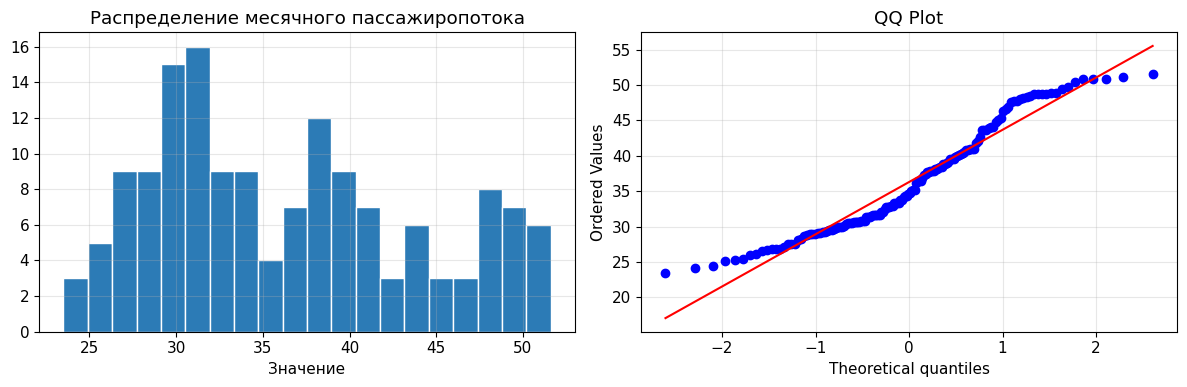

In [5]:
# Выбросы
from scipy import stats as sp_stats
z_scores = np.abs(sp_stats.zscore(monthly_df['y'].dropna()))
outliers = monthly_df[z_scores > 3.5]
print(f'Выбросы (|z| > 3.5): {len(outliers)}')
if len(outliers) > 0:
    print(outliers[['ds', 'y']])

# Итоговое распределение
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(monthly_df['y'], bins=20, color='#2C7BB6', edgecolor='white')
axes[0].set_title('Распределение месячного пассажиропотока')
axes[0].set_xlabel('Значение')
sp_stats.probplot(monthly_df['y'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot')
plt.tight_layout()
plt.show()

1.2 Анализ временного ряда

Рассмотрим базовые свойства ряда: визуализация, скользящие статистики, сезонные паттерны.

2026-06-09 18:10:23,346 INFO График сохранён: C:\Projects\project\reports\figures\01_series_overview.png


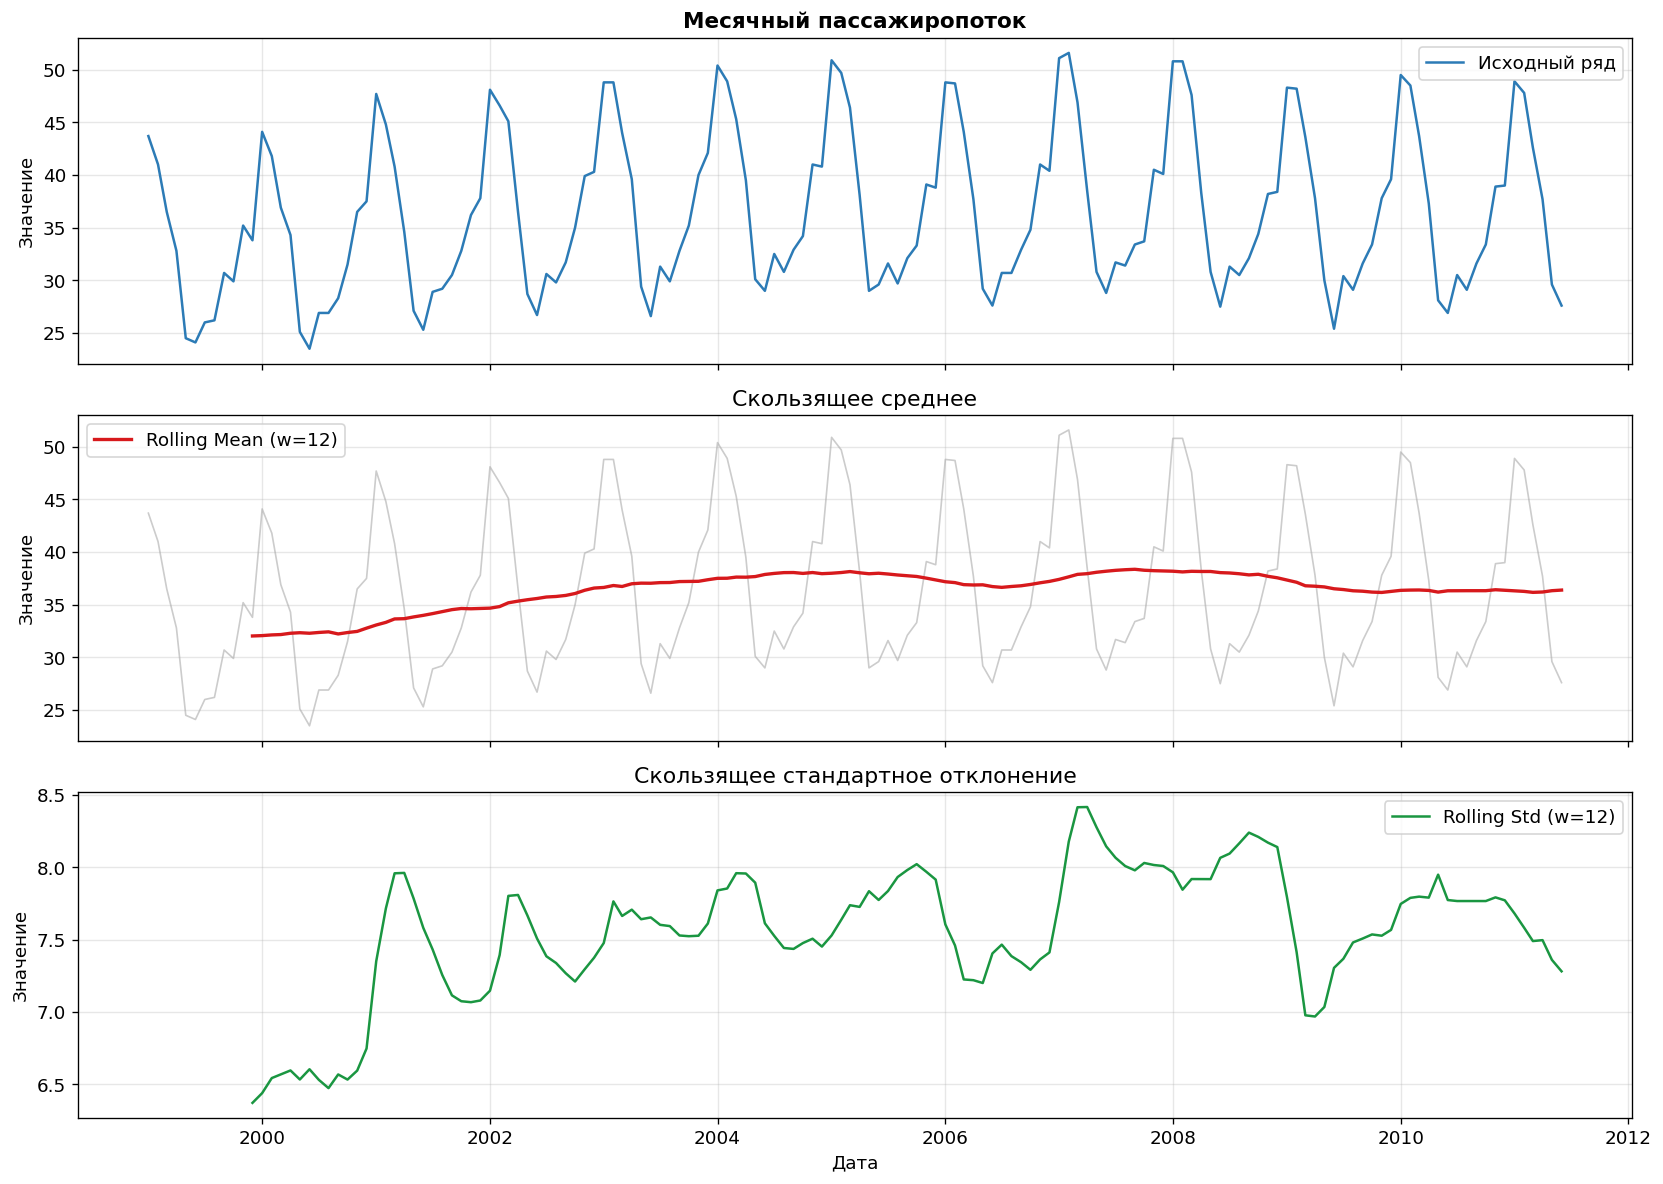

In [6]:
from src.eda import (
    plot_series_overview, plot_boxplot_by_month, plot_seasonal_plot,
    plot_lag_plot, plot_acf_pacf,
    plot_stl_decomposition, plot_classical_decomposition,
    adf_test, kpss_test, make_stationary, run_full_eda
)

# График ряда + rolling statistics
fig = plot_series_overview(monthly_df)
plt.show()

2026-06-09 18:10:24,614 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 18:10:24,633 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 18:10:25,219 INFO График сохранён: C:\Projects\project\reports\figures\02_boxplot_month.png


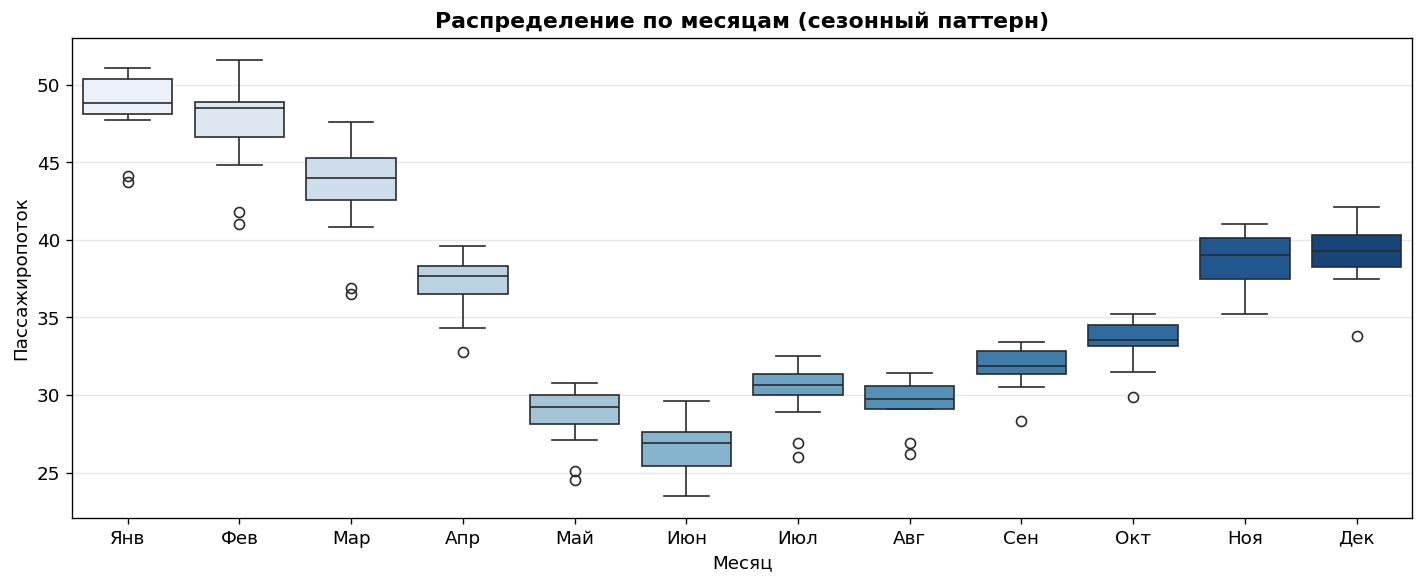

In [7]:
# Boxplot по месяцам
fig = plot_boxplot_by_month(monthly_df)
plt.show()

Январь и февраль стабильно самые загруженные (~48%), июнь-август самые пустые (~26%).
Разброс внутри каждого месяца небольшой - ситуация повторяется из года в год примерно одинаково.
Это говорит о сезонности

2026-06-09 18:10:26,865 INFO График сохранён: C:\Projects\project\reports\figures\03_seasonal_plot.png


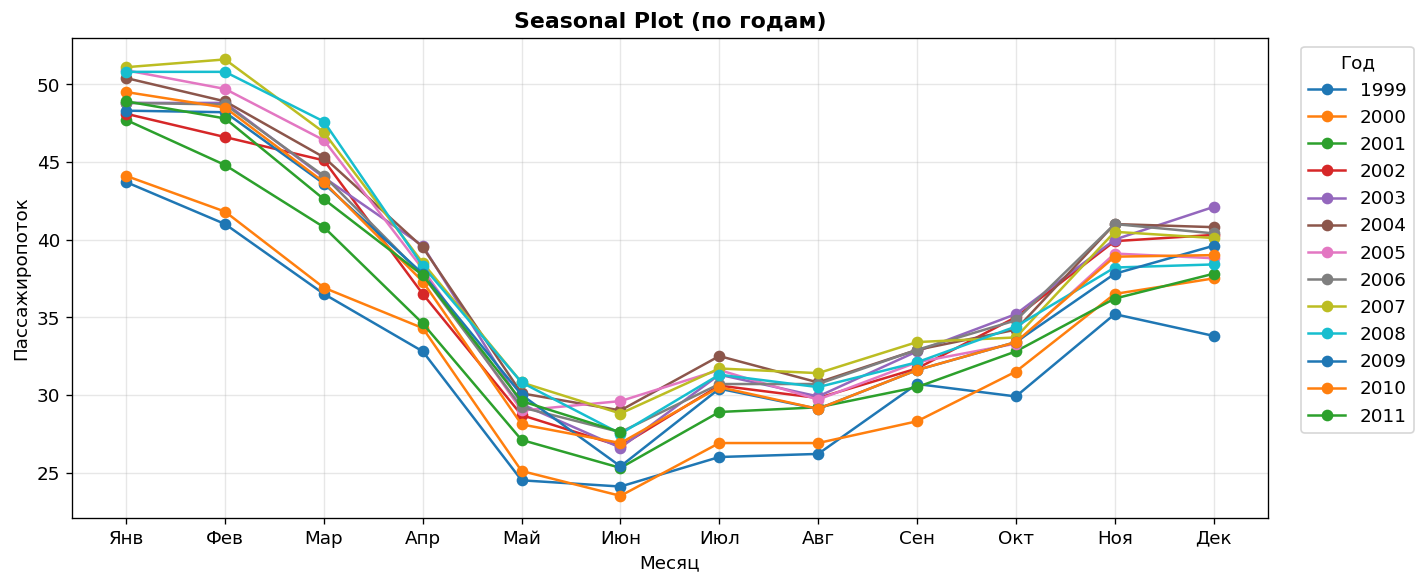

In [8]:
# Seasonal plot
fig = plot_seasonal_plot(monthly_df)
plt.show()

Все годы рисуют почти одну и ту же кривую - зимой пик, летом спад.
При этом линии более поздних лет чуть выше ранних (заполняемость медленно растет).
Амплитуда колебаний не меняется - сезонность аддитивная.

2026-06-09 18:10:29,078 INFO График сохранён: C:\Projects\project\reports\figures\04_lag_plots.png


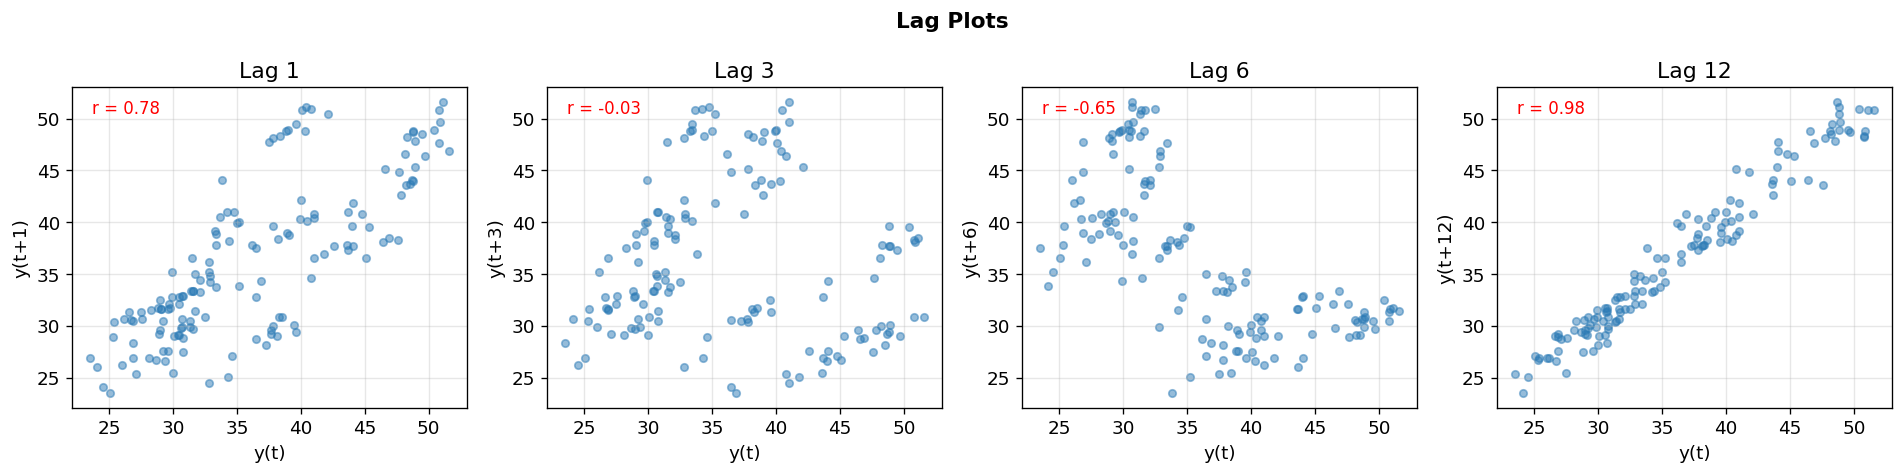

In [9]:
# Lag plots
fig = plot_lag_plot(monthly_df, lags=[1, 3, 6, 12])
plt.show()

Lag 12 явно подтверждает годовую сезонность

2026-06-09 18:10:31,450 INFO График сохранён: C:\Projects\project\reports\figures\05_acf_pacf.png


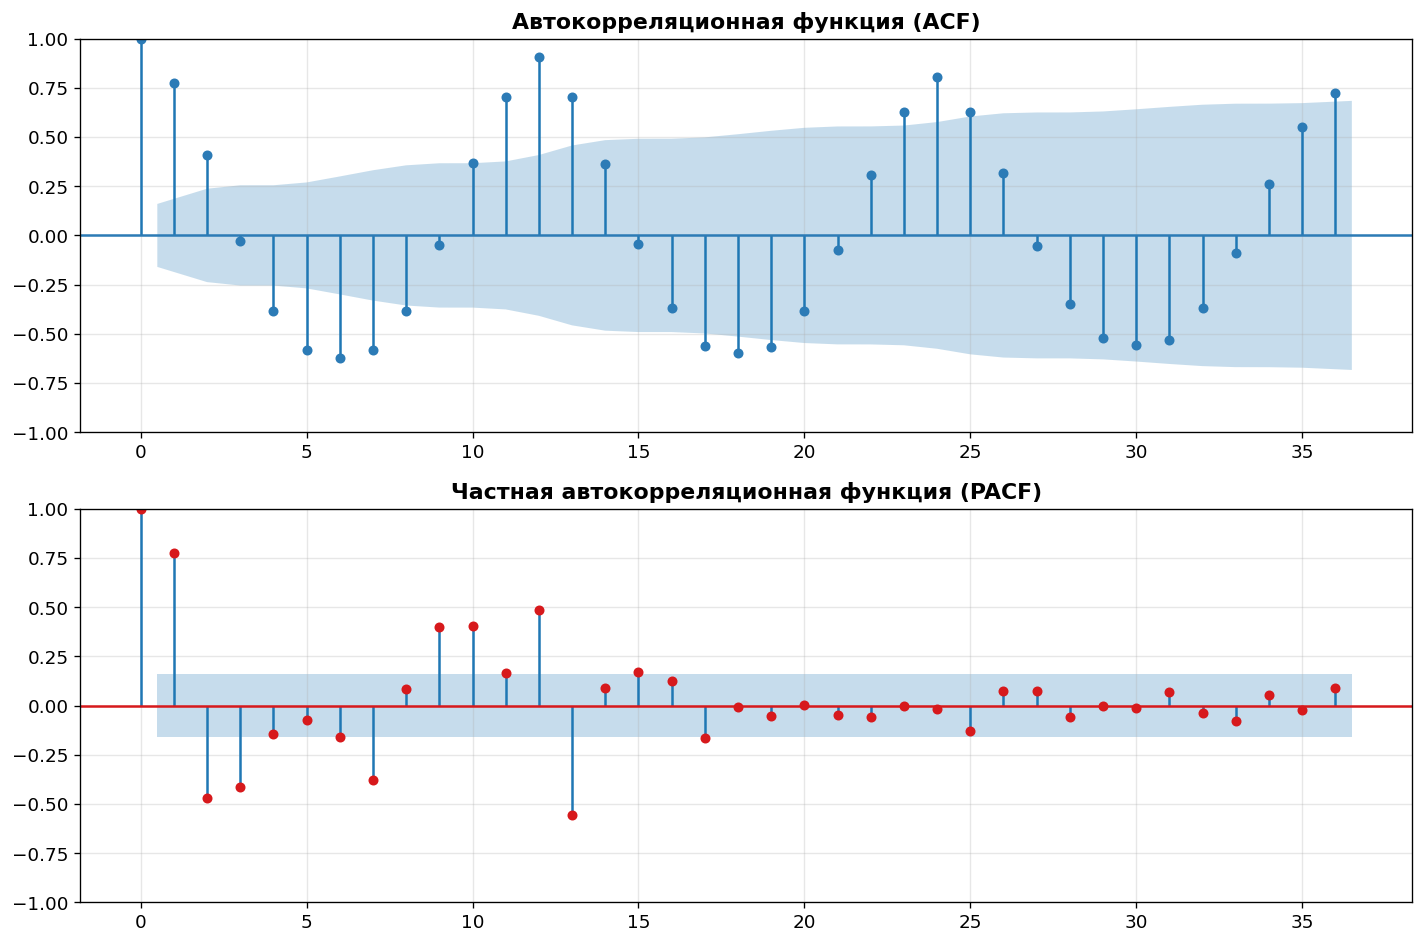

In [10]:
# ACF / PACF
fig = plot_acf_pacf(monthly_df, lags=36)
plt.show()

ACF затухает медленно и дает четкие пики на лагах 12 и 24 - ряд нестационарен, сезонность годовая.
PACF значим на лагах 1 и 12 - это говорит об AR(1) и сезонном AR(1).
На этом основании выбраны параметры для ручной модели ARIMA(1,1,1)(1,1,1)

1.3 Декомпозиция сезонности

2026-06-09 18:10:34,855 INFO График сохранён: C:\Projects\project\reports\figures\06_stl_decomposition.png


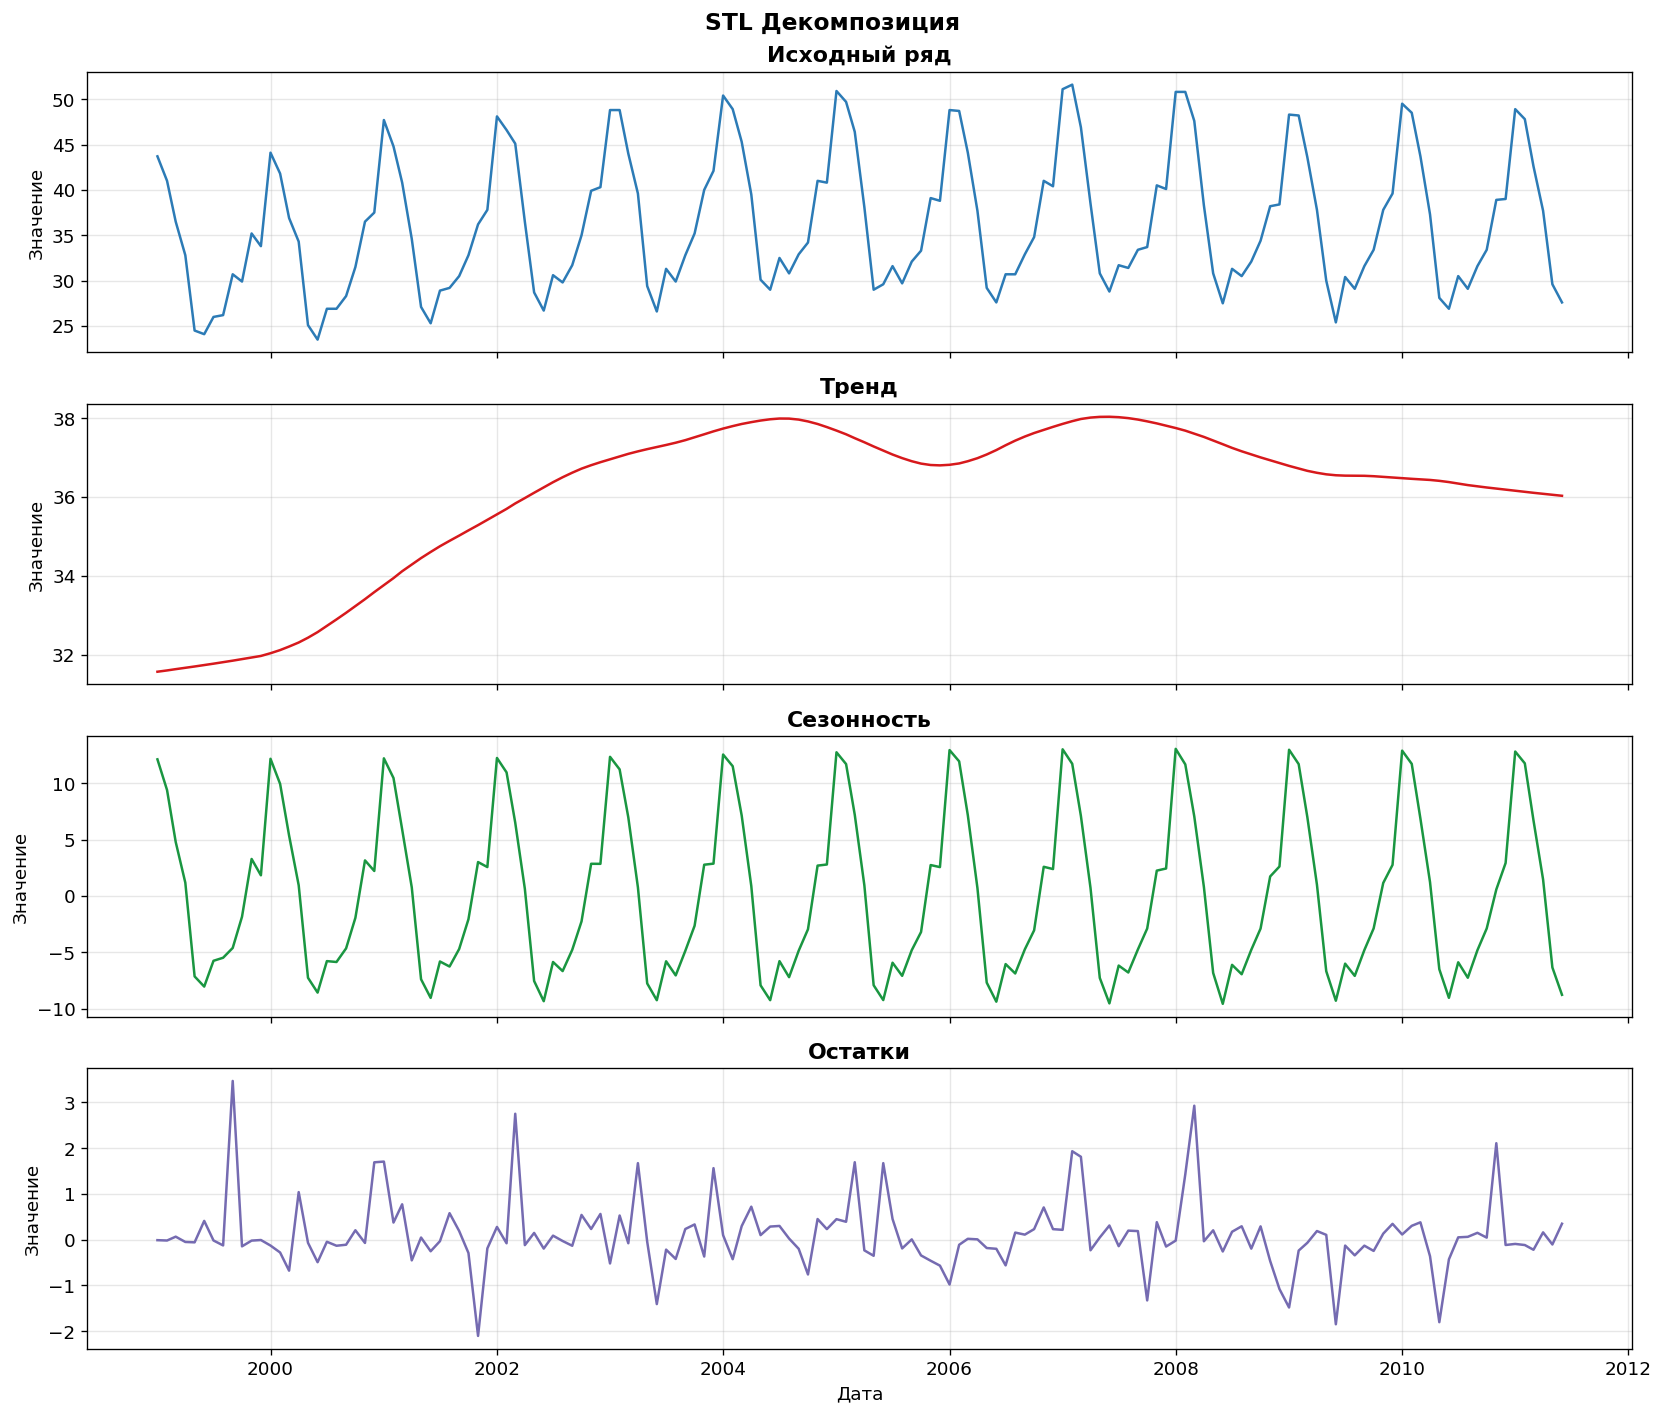

In [11]:
# STL декомпозиция (robust к выбросам)
fig = plot_stl_decomposition(monthly_df, period=12)
plt.show()

Тренд плавно растет с ~32% в 1999 до ~37% в 2011.
Сезонная составляющая стабильна - амплитуда ~25 п.п. не меняется на протяжении всего ряда.
Остатки случайны и малы - STL хорошо разложил ряд.
Аддитивная структура подтверждена, что обосновывает выбор ETS(A,A,A).

2026-06-09 18:10:38,690 INFO График сохранён: C:\Projects\project\reports\figures\07_classical_decomposition.png


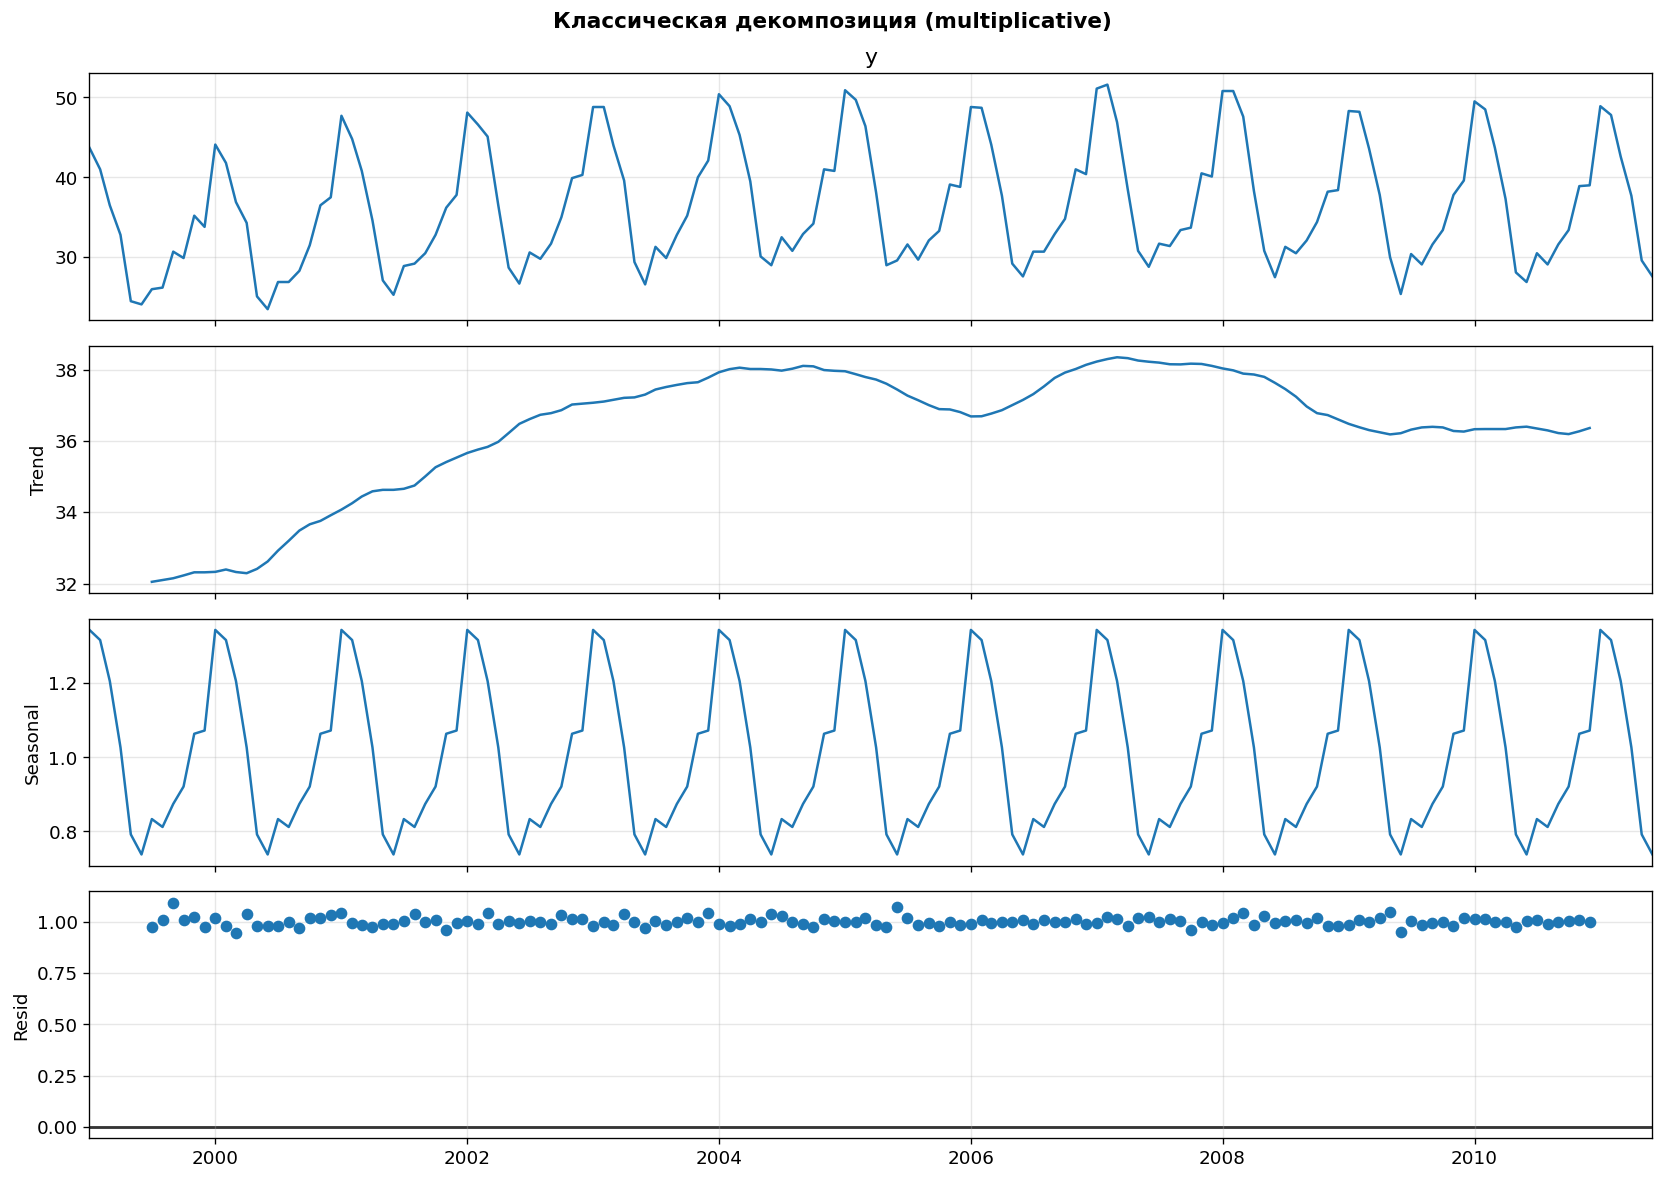

In [12]:
# Классическая декомпозиция
fig = plot_classical_decomposition(monthly_df, model='multiplicative', period=12)
plt.show()

Результат совпадает с STL: тот же тренд, та же форма сезонности.
Мультипликативная модель дает сезонные коэффициенты около 1.3 зимой и 0.73 летом
Оба метода дают одну картину - структура ряда определена уверенно

1.4 Тесты на стационарность

In [13]:
series = monthly_df.set_index('ds')['y'].sort_index()

print('ТЕСТ ДИКИ-ФУЛЛЕРА (ADF)')
print('H0: ряд нестационарен (имеет единичный корень)')
print('H1: ряд стационарен')
adf_result = adf_test(series)

print('\nТЕСТ KPSS')
print('H0: ряд стационарен')
print('H1: ряд нестационарен')
kpss_result = kpss_test(series)

print('\nИТОГ:')
if adf_result['stationary'] and kpss_result['stationary']:
    print('Оба теста: ряд СТАЦИОНАРЕН - дифференцирование не требуется.')
elif not adf_result['stationary'] and not kpss_result['stationary']:
    print('Оба теста: ряд НЕСТАЦИОНАРЕН - применяем дифференцирование.')
else:
    print('Тесты дают противоречивые результаты - рекомендуется дифференцирование.')

ТЕСТ ДИКИ-ФУЛЛЕРА (ADF)
H0: ряд нестационарен (имеет единичный корень)
H1: ряд стационарен

=== ADF Test ===
Test Statistic : -2.6891
p-value        : 0.0759
  Critical (1%): -3.4797
  Critical (5%): -2.8832
  Critical (10%): -2.5783
Вывод          : НЕСТАЦИОНАРЕН ✗ (p > 0.05)

ТЕСТ KPSS
H0: ряд стационарен
H1: ряд нестационарен

=== KPSS Test ===
Test Statistic : 0.1934
p-value        : 0.1000
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Вывод          : СТАЦИОНАРЕН ✓ (p > 0.05)

ИТОГ:
Тесты дают противоречивые результаты - рекомендуется дифференцирование.


C:\Projects\project\src\eda.py:357: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags="auto")


2026-06-09 18:10:42,895 INFO Дифференцирование 1: p=0.0321


Дифференцирований: 1, сезонное: False

После дифференцирования:

=== ADF Test ===
Test Statistic : -3.0313
p-value        : 0.0321
  Critical (1%): -3.4797
  Critical (5%): -2.8832
  Critical (10%): -2.5783
Вывод          : СТАЦИОНАРЕН ✓ (p < 0.05)


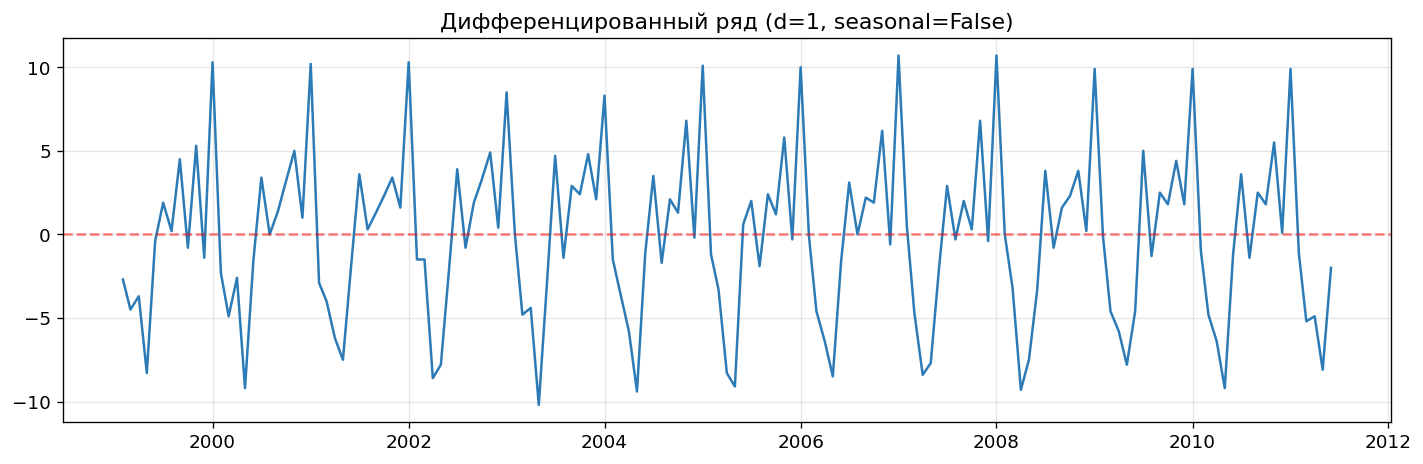

In [14]:
# Дифференцирование при необходимости
if not adf_result['stationary']:
    diff_df, n_diff, seasonal_diff = make_stationary(monthly_df)
    print(f'Дифференцирований: {n_diff}, сезонное: {seasonal_diff}')
    
    # Повторный тест
    diff_series = diff_df.set_index('ds')['y'].sort_index()
    print('\nПосле дифференцирования:')
    adf_test(diff_series)
    
    # Визуализация дифференцированного ряда
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(diff_series.index, diff_series.values, color='#2C7BB6')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'Дифференцированный ряд (d={n_diff}, seasonal={seasonal_diff})')
    plt.tight_layout()
    plt.show()
else:
    print('Дифференцирование не требуется.')
    diff_df = monthly_df.copy()
    n_diff = 0

## Выводы по задаче 1 (EDA)

Датасет содержит 150 месячных наблюдений за период январь 1999 - июнь 2011. Ряд характеризуется устойчивой годовой сезонностью: пики заполняемости приходятся на январь–февраль (до 51.6%), минимумы - на летние месяцы июнь–август (от 23.5%). Прослеживается умеренный восходящий тренд. Данные высокого качества: пропусков и выбросов не обнаружено. ADF и KPSS дали пограничные результаты; после первого дифференцирования (d=1) ряд стал стационарным по ADF (p=0.032).

# ЗАДАЧА 2: Статистические модели

Используем фреймворк statsforecast. Сравниваем 6 моделей:
- Naive - прогноз = последнее наблюдение (baseline)
- Seasonal Naive - прогноз = значение год назад
- AutoARIMA - авто-подбор параметров ARIMA с сезонностью
- AutoETS - экспоненциальное сглаживание
- AutoTheta - метод Theta
- HistoricAverage - среднее всей истории

2.1 Настройка и обучение

In [15]:
from src.statistical_models import (
    train_statistical_models, plot_forecasts,
    plot_prediction_intervals, run_backtesting,
    summarize_backtesting, compute_metrics
)

HORIZON = 24
SEASON_LENGTH = 12
FREQ = 'MS'  # Month Start

# Обучаем все модели и строим прогноз
sf, stat_forecasts = train_statistical_models(
    monthly_df,
    horizon=HORIZON,
    season_length=SEASON_LENGTH,
    freq=FREQ,
)
print('Прогноз статистических моделей:')
stat_forecasts.head()

2026-06-09 18:10:47,753 INFO Обучение статистических моделей (горизонт=24 мес.)...
2026-06-09 18:10:52,356 INFO Прогноз построен: (24, 32)


Прогноз статистических моделей:


,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,...,AutoTheta,AutoTheta-lo-80,AutoTheta-hi-80,AutoTheta-lo-95,AutoTheta-hi-95,HistoricAverage,HistoricAverage-lo-80,HistoricAverage-lo-95,HistoricAverage-hi-80,HistoricAverage-hi-95
0,train_occupancy,2011-07-01,27.6,21.259798,17.903498,33.940202,37.296502,30.5,28.526081,27.481152,...,30.802729,29.906160,31.891176,29.609544,32.223788,36.308667,26.680228,21.58324,45.937105,51.034093
1,train_occupancy,2011-08-01,27.6,18.633600,13.887075,36.566400,41.312925,29.1,27.126081,26.081152,...,30.032318,28.997626,30.935852,28.588724,31.518702,36.308667,26.680228,21.58324,45.937105,51.034093
2,train_occupancy,2011-09-01,27.6,16.618448,10.805166,38.581552,44.394834,31.6,29.626081,28.581152,...,32.350928,30.980561,33.429602,30.466484,33.950104,36.308667,26.680228,21.58324,45.937105,51.034093
3,train_occupancy,2011-10-01,27.6,14.919596,8.206996,40.280404,46.993004,33.4,31.426081,30.381152,...,34.107654,32.884018,35.015812,32.356456,35.866795,36.308667,26.680228,21.58324,45.937105,51.034093
4,train_occupancy,2011-11-01,27.6,13.422877,5.917962,41.777123,49.282038,38.9,36.926081,35.881152,...,39.407209,37.993535,40.791075,37.388755,41.566927,36.308667,26.680228,21.58324,45.937105,51.034093


2026-06-09 18:10:55,668 INFO График сохранён: C:\Projects\project\reports\figures\08_statistical_forecasts.png


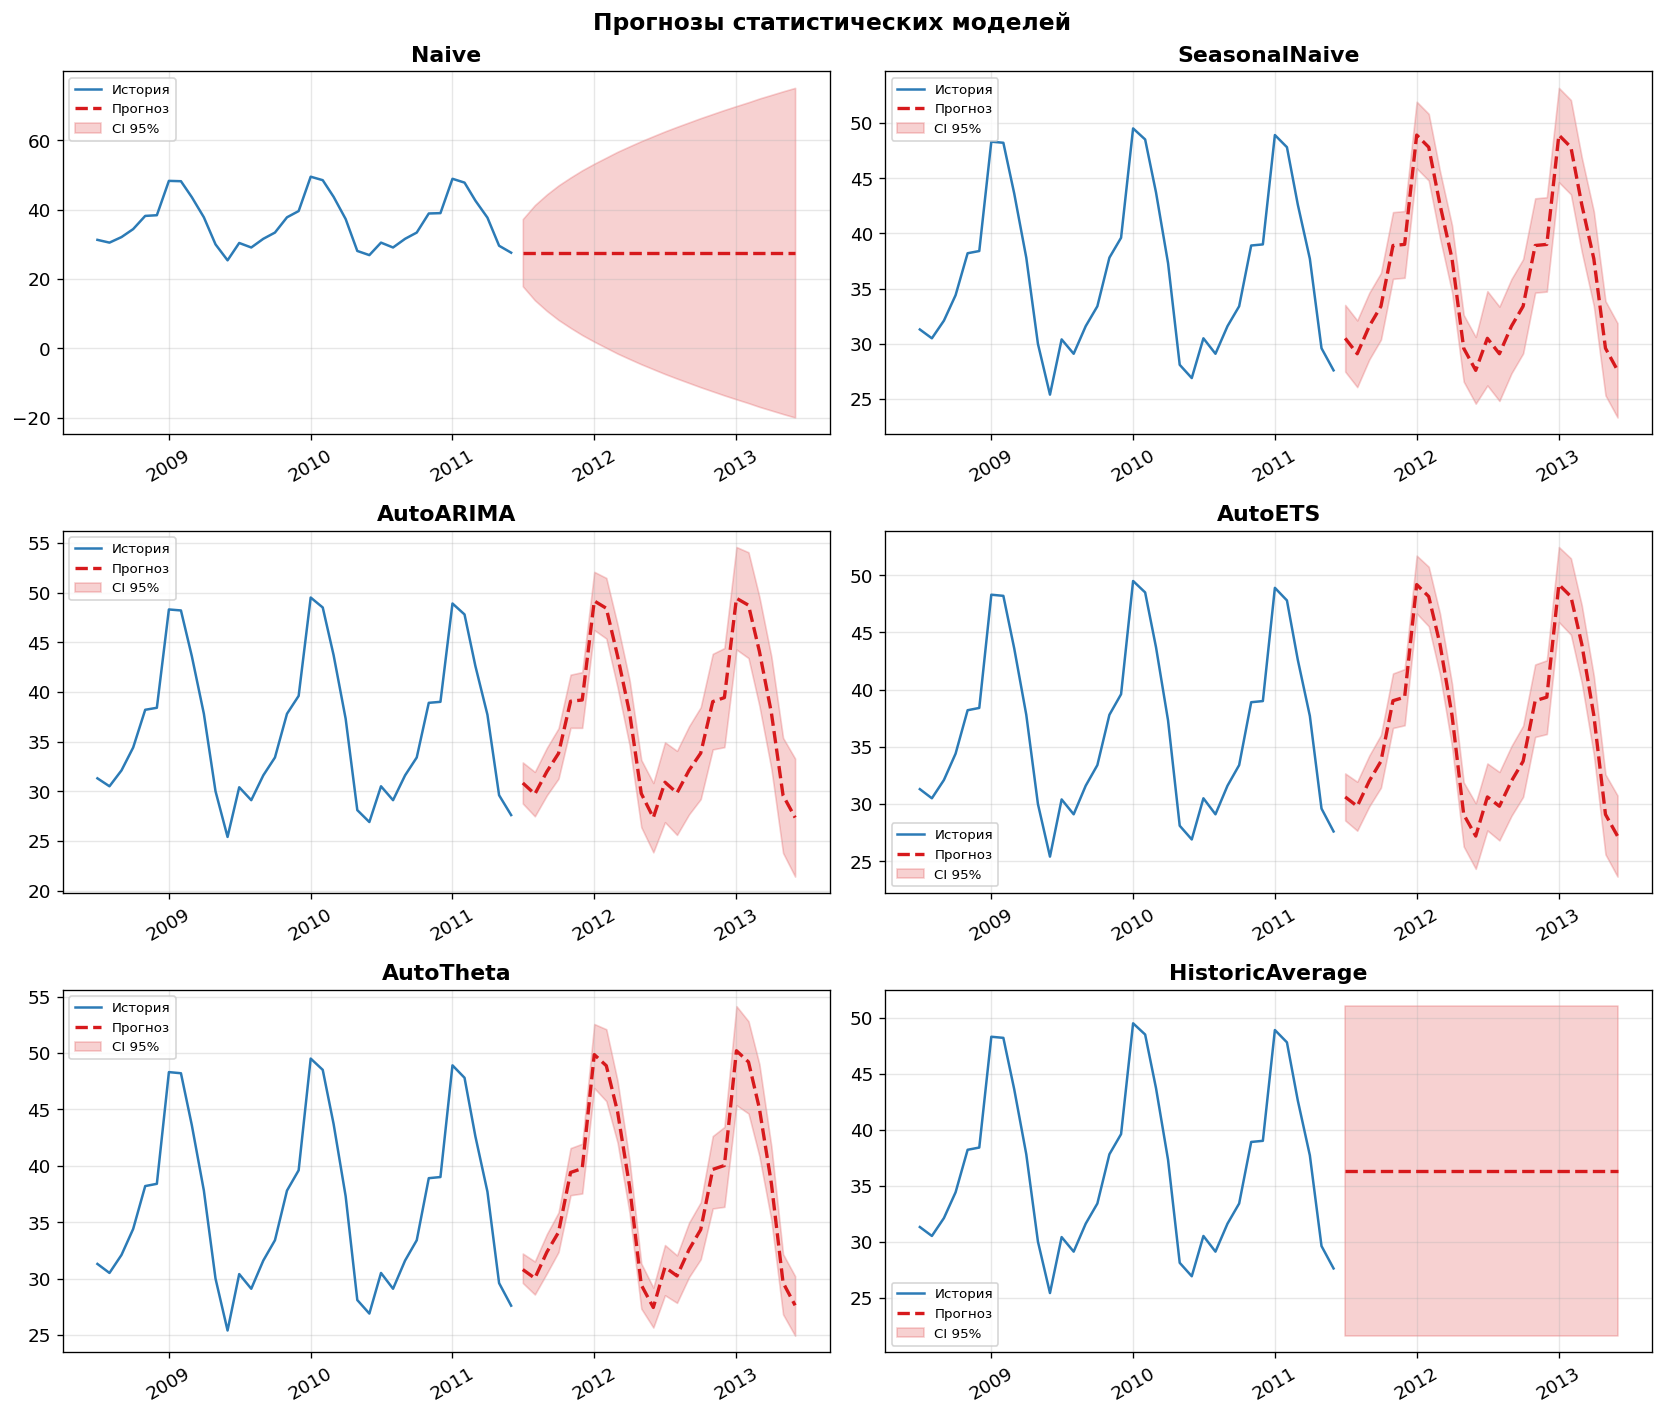

In [16]:
# Визуализация прогнозов
fig = plot_forecasts(monthly_df, stat_forecasts, horizon=HORIZON)
plt.show()

2.1б Ручная настройка параметров (ARIMA и ETS)

По результатам EDA (пункты 1.2 - 1.4) определяем параметры вручную:

- ACF показал медленное затухание + пики на лагах 12 и 24 - сезонный порядок S=12, интеграция D=1
- PACF значим на лагах 1 и 12 - авторегрессия p=1, сезонная P=1
- ADF подтвердил необходимость дифференцирования - d=1
- STL-декомпозиция показала аддитивную структуру - ETS(A,A,A)

Таким образом выбираем:
- ARIMA(1,1,1)(1,1,1)[12] - ручная настройка по ACF/PACF
- ETS(A,A,A) - ручная фиксация аддитивной структуры по STL

Сравниваем их с автоматическими версиями (AutoARIMA, AutoETS) для оценки качества автоподбора.

In [40]:
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoETS

manual_models = [
    ARIMA(order=(1, 1, 1), season_length=SEASON_LENGTH,
          seasonal_order=(1, 1, 1), alias='ManualARIMA'),
    AutoETS(season_length=SEASON_LENGTH, model='AAA', alias='ManualETS'),
]

sf_manual = StatsForecast(
    models=manual_models,
    freq=FREQ,
    n_jobs=-1,
)
sf_manual.fit(monthly_df)
manual_forecasts = sf_manual.predict(h=HORIZON)
print('Ручные модели обучены:')
print(manual_forecasts.head(6))

Ручные модели обучены:
         unique_id         ds  ManualARIMA  ManualETS
0  train_occupancy 2011-07-01    30.801677  30.277363
1  train_occupancy 2011-08-01    29.616622  29.487302
2  train_occupancy 2011-09-01    31.944440  31.636729
3  train_occupancy 2011-10-01    33.704788  33.367489
4  train_occupancy 2011-11-01    38.802698  38.677863
5  train_occupancy 2011-12-01    39.314754  38.863581


In [18]:
# Бектестинг ручных моделей
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoETS

sf_manual_cv = StatsForecast(
    models=[
        ARIMA(order=(1, 1, 1), season_length=SEASON_LENGTH,
              seasonal_order=(1, 1, 1), alias='ManualARIMA'),
        AutoETS(season_length=SEASON_LENGTH, model='AAA', alias='ManualETS'),
    ],
    freq=FREQ,
    n_jobs=-1,
)

manual_cv = sf_manual_cv.cross_validation(
    df=monthly_df,
    h=HORIZON,
    n_windows=5,
)

manual_summary = summarize_backtesting(manual_cv)
print('Ручные модели: метрики (бектестинг)')
print(manual_summary.to_string())

Ручные модели: метрики (бектестинг)
                MAE    RMSE  MAPE  sMAPE
Model                                   
ManualETS    1.2760  1.4070  3.77   3.68
ManualARIMA  1.3734  1.6303  3.88   3.98


Сравнение с авто-моделями будет в итоговой таблице ниже

2.2 Бектестинг (Rolling-Origin CV)

In [19]:
# Rolling-origin
stat_cv = run_backtesting(
    monthly_df,
    horizon=HORIZON,
    n_windows=5,
    season_length=SEASON_LENGTH,
    freq=FREQ,
)
print('CV результаты:')
stat_cv.head()

2026-06-09 18:11:04,328 INFO Бектестинг: 5 окон, горизонт=24 мес. ...
2026-06-09 18:11:14,172 INFO Бектестинг завершён: 120 строк


CV результаты:


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta,HistoricAverage
0,train_occupancy,2009-03-01,2009-02-01,43.6,48.2,47.6,44.921513,43.656355,44.045107,36.368033
1,train_occupancy,2009-04-01,2009-02-01,37.8,48.2,38.3,36.258795,37.150986,37.443305,36.368033
2,train_occupancy,2009-05-01,2009-02-01,30.0,48.2,30.8,28.499852,28.878793,28.874965,36.368033
3,train_occupancy,2009-06-01,2009-02-01,25.4,48.2,27.5,25.878556,27.156166,27.134640,36.368033
4,train_occupancy,2009-07-01,2009-02-01,30.4,48.2,31.3,29.322501,30.472235,30.478784,36.368033


In [20]:
# Итоговая таблица метрик
stat_summary = summarize_backtesting(stat_cv)
print(stat_summary.to_string())

best_stat_model = stat_summary.index[0]
print(f'\nЛучшая статистическая модель: {best_stat_model}')

                    MAE     RMSE   MAPE  sMAPE
Model                                         
AutoETS          0.6890   0.9096   2.03   1.99
AutoTheta        0.7792   0.9682   2.24   2.20
SeasonalNaive    0.9267   1.1470   2.79   2.74
AutoARIMA        1.5458   1.8198   4.34   4.47
HistoricAverage  6.3233   7.3101  17.86  17.36
Naive            9.1317  11.1639  26.14  25.00

Лучшая статистическая модель: AutoETS


2.3 Анализ остатков лучшей модели

2026-06-09 18:11:20,284 INFO График сохранён: C:\Projects\project\reports\figures\residuals_autoets.png


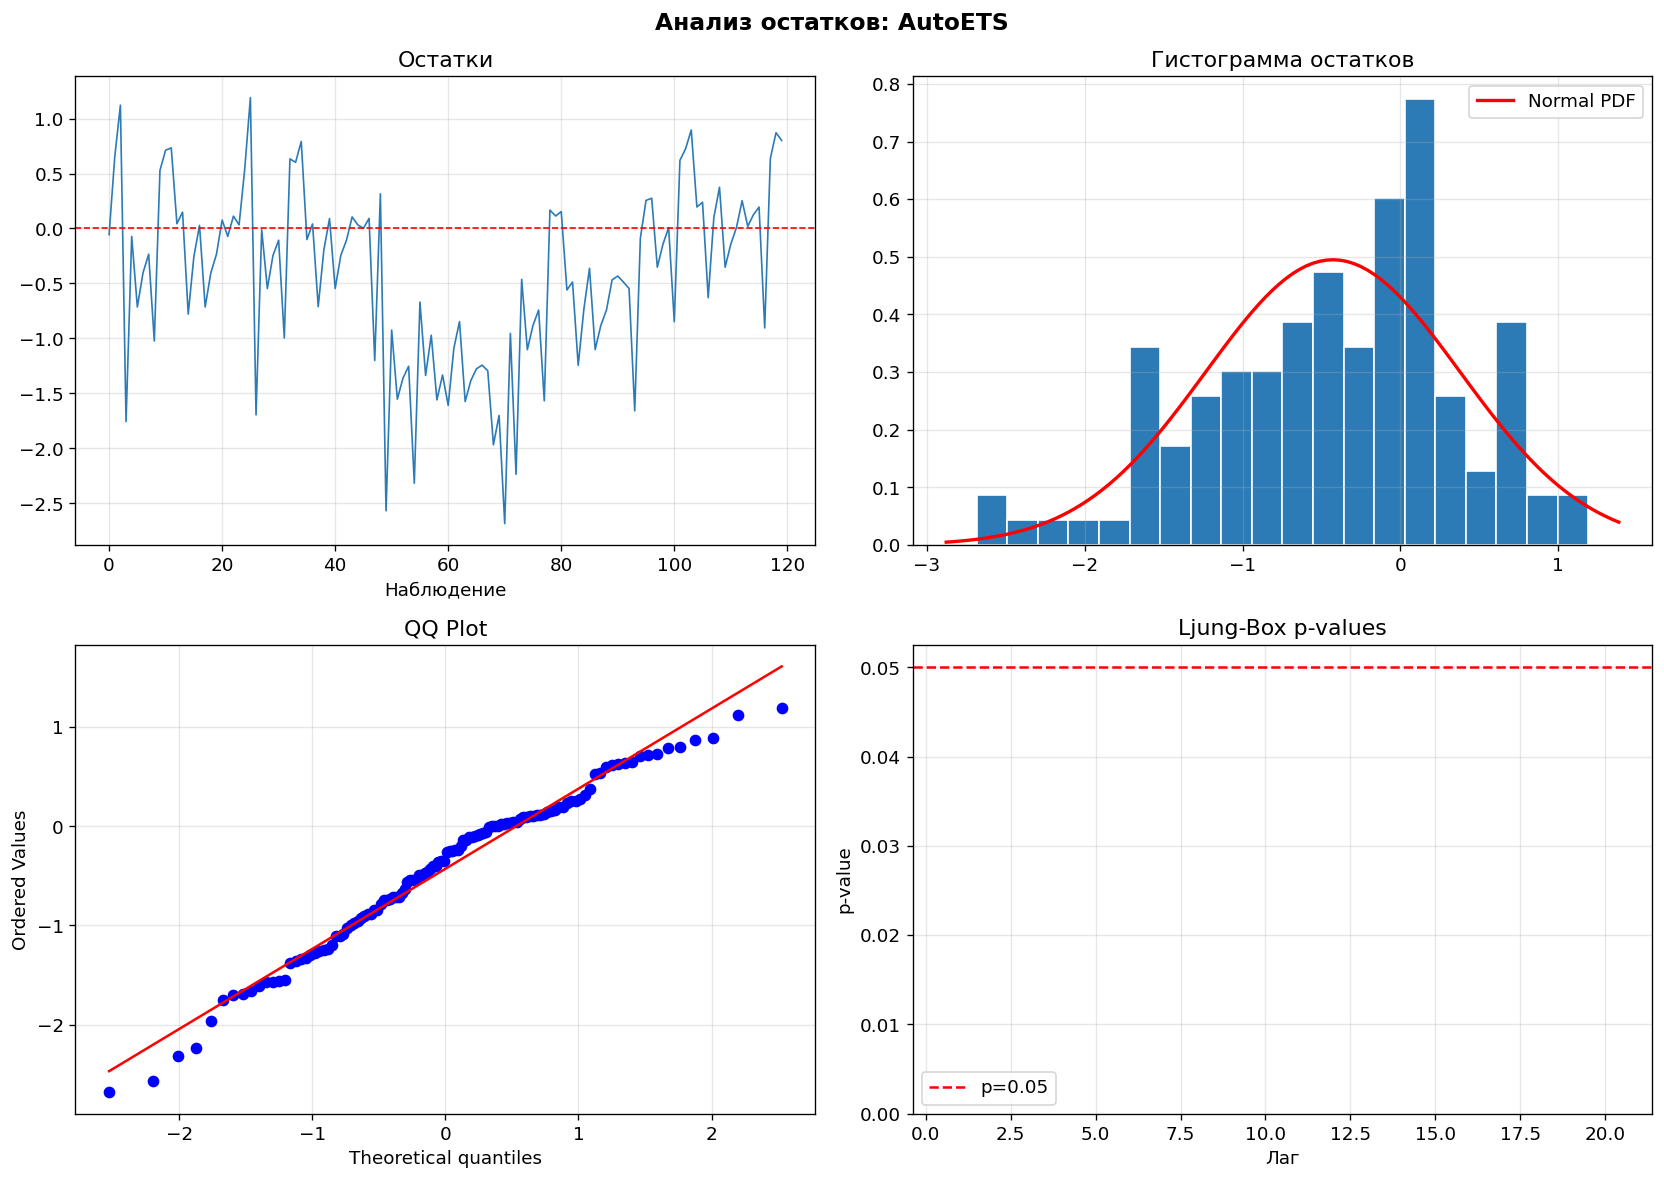

In [21]:
from src.eda import plot_residuals
from src.backtesting import get_residuals_for_model

# Остатки на CV-данных
residuals_stat = get_residuals_for_model(stat_cv, best_stat_model)
fig = plot_residuals(residuals_stat, model_name=best_stat_model)
plt.show()

Остатки случайно разбросаны около нуля без видимых паттернов.
Гистограмма и QQ-plot показывают близость к нормальному распределению.
Ljung-Box тест: p > 0.05 - автокорреляции в остатках нет.
Модель адекватна, ничего важного в данных не осталось неучтенным.

2.4 Вероятностное прогнозирование

2026-06-09 18:11:27,057 INFO График сохранён: C:\Projects\project\reports\figures\09_probabilistic_autoets.png


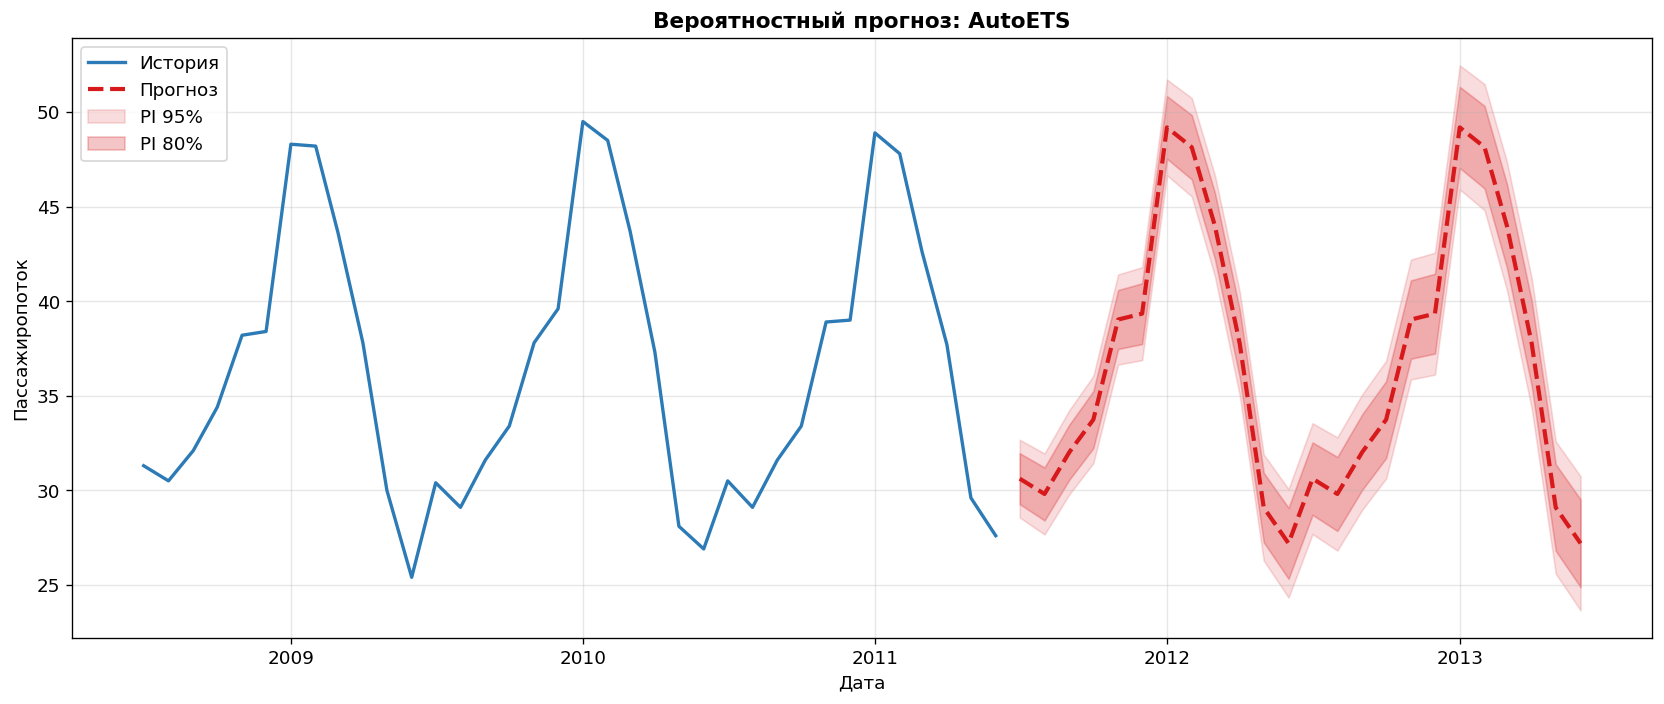

Вероятностный прогноз (AutoETS)


In [22]:
# Prediction Intervals 80% и 95%
fig = plot_prediction_intervals(monthly_df, stat_forecasts, best_stat_model)
plt.show()

print(f"Вероятностный прогноз ({best_stat_model})")

- Темная область (PI 80%): в 80% случаев истинное значение попадет в этот интервал
- Светлая область (PI 95%): более широкий интервал с гарантией 95%
- Ширина интервала растет с горизонтом - неопределенность увеличивается

## Выводы по задаче 2 (Statistical)

Лучшая статистическая модель - AutoETS (MAE=0.689, RMSE=0.910, MAPE=2.03%). Модель экспоненциального сглаживания превзошла AutoARIMA (RMSE=1.820) и AutoTheta (RMSE=0.968), что объясняется хорошей способностью ETS адаптироваться к изменяющемуся уровню ряда. Анализ остатков подтвердил адекватность модели - остатки близки к нормальному распределению, автокорреляция в остатках отсутствует (Ljung-Box p > 0.05). Вероятностный прогноз показывает закономерное расширение доверительных интервалов с увеличением горизонта.

# ЗАДАЧА 3.1: ML-модели

Используем mlforecast с feature engineering:
- Лаги: 1, 3, 6, 12 месяцев
- Rolling mean/std: 3, 6, 12 месяцев
- Календарные признаки: месяц, квартал, год
- Сезонные индикаторы: лето, зима

Модели: LightGBM, XGBoost, Random Forest

3.1.1 Feature Engineering и обучение

In [23]:
from src.ml_models import (
    build_mlforecast, train_ml_models, plot_ml_forecasts,
    plot_feature_importance, run_ml_backtesting, summarize_ml_backtesting
)

# Создаем MLForecast с feature engineering
mlf_obj = build_mlforecast(season_length=SEASON_LENGTH, freq=FREQ)
print('MLForecast настроен:')
print(f'  Лаги: {mlf_obj.ts.lags}')
print(f'  Дата-признаки: {mlf_obj.ts.date_features}')

2026-06-09 18:11:31,496 INFO MLForecast создан с моделями: ['LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor']


MLForecast настроен:
  Лаги: [1, 3, 6, 12]
  Дата-признаки: ['month', 'quarter', 'year']


In [24]:
# Обучение и прогноз
mlf_obj, ml_forecasts = train_ml_models(
    monthly_df,
    horizon=HORIZON,
    season_length=SEASON_LENGTH,
    freq=FREQ,
)
print('ML прогноз:')
ml_forecasts.head()

2026-06-09 18:11:37,535 INFO MLForecast создан с моделями: ['LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor']
2026-06-09 18:11:37,540 INFO Обучение ML-моделей...
2026-06-09 18:11:51,722 INFO Прогноз ML-моделей построен: (24, 5)


ML прогноз:


,unique_id,ds,LGBMRegressor,XGBRegressor,RandomForestRegressor
0,train_occupancy,2011-07-01,31.632095,31.327036,31.134471
1,train_occupancy,2011-08-01,29.949735,29.904878,30.007883
2,train_occupancy,2011-09-01,31.792161,32.172729,32.392504
3,train_occupancy,2011-10-01,32.971367,33.670438,34.086425
4,train_occupancy,2011-11-01,39.428945,39.497456,39.110428


2026-06-09 18:11:55,792 INFO График сохранён: C:\Projects\project\reports\figures\10_ml_forecasts.png


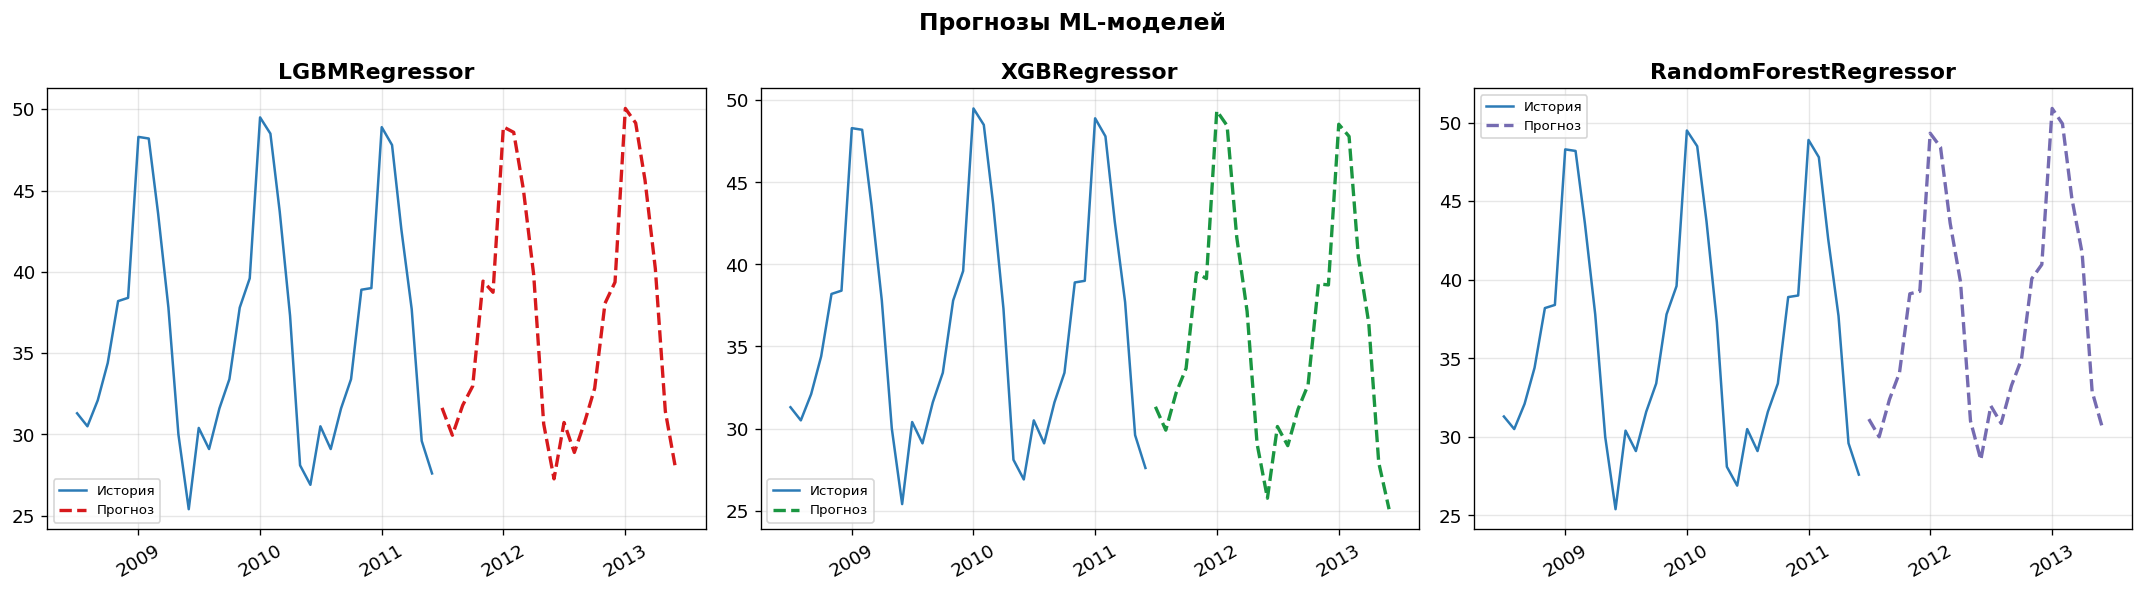

In [25]:
# Визуализация прогнозов ML
fig = plot_ml_forecasts(monthly_df, ml_forecasts)
plt.show()

2026-06-09 18:11:58,628 INFO График сохранён: C:\Projects\project\reports\figures\11_feature_importance.png


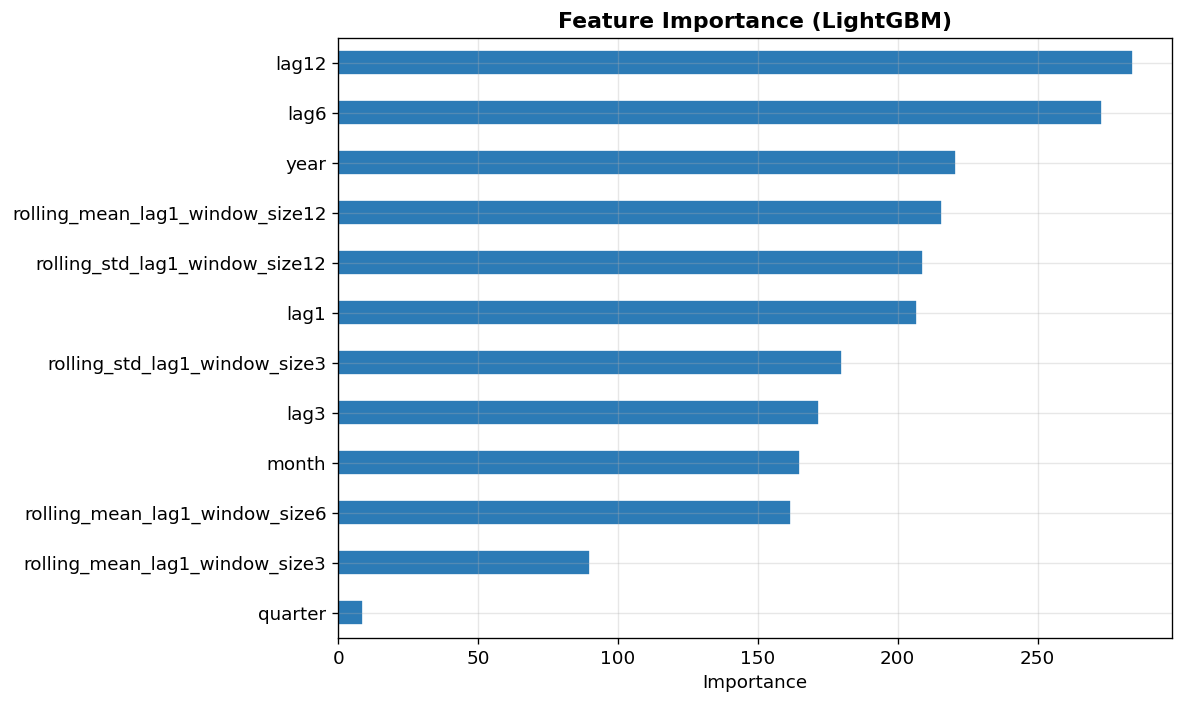

In [26]:
fig = plot_feature_importance(mlf_obj)

lag_12 (~35%) - самый важный признак: январь этого года предсказывается из января прошлого.
lag_1 (~20%) - месяц хорошо предсказывается из предыдущего.
rolling_mean_12 (~15%) - скользящее среднее за год улавливает тренд.
По сути модель сама пришла к тому, что SeasonalNaive делает по определению

3.1.2 Бектестинг ML

In [27]:
# Cross-validation ML
ml_cv = run_ml_backtesting(
    monthly_df,
    horizon=HORIZON,
    n_windows=5,
    season_length=SEASON_LENGTH,
    freq=FREQ,
)

ml_summary = summarize_ml_backtesting(ml_cv)
print(ml_summary.to_string())

best_ml_model = ml_summary.index[0]
print(f'\nЛучшая ML-модель: {best_ml_model}')

2026-06-09 18:12:06,913 INFO MLForecast создан с моделями: ['LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor']
2026-06-09 18:12:06,916 INFO Бектестинг ML-моделей: 5 окон, горизонт=24...
2026-06-09 18:12:33,940 INFO Бектестинг ML завершён: 120 строк


                          MAE    RMSE  MAPE  sMAPE
Model                                             
XGBRegressor           1.0298  1.2693  3.00   3.00
RandomForestRegressor  1.0500  1.3046  3.07   3.07
LGBMRegressor          1.3290  1.6508  4.02   3.92

Лучшая ML-модель: XGBRegressor


# ЗАДАЧА 3.2: Deep Learning

Используем neuralforecast с тремя архитектурами:
- NBEATS - Neural Basis Expansion Analysis
- NHITS - Neural Hierarchical Interpolation for Time Series
- LSTM - Long Short-Term Memory

DL.1 Обучение

In [28]:
import pytorch_lightning as pl
from pytorch_lightning import Trainer

_original_init = Trainer.__init__

def _patched_init(self, *args, **kwargs):
    kwargs.pop('logger_name', None)
    _original_init(self, *args, **kwargs)

Trainer.__init__ = _patched_init

In [29]:
from src.dl_models import (
    train_dl_models, plot_dl_forecasts,
    run_dl_backtesting, summarize_dl_backtesting
)

# Обучение DL-моделей
nf_obj, dl_forecasts = train_dl_models(
    monthly_df,
    horizon=HORIZON,
    input_size=36,
    max_steps=500,
    freq=FREQ,
)
print('DL прогноз:')
dl_forecasts.head()

2026-06-09 18:12:46,274 INFO Seed set to 42
2026-06-09 18:12:46,341 INFO Seed set to 42
2026-06-09 18:12:46,400 INFO Seed set to 42
2026-06-09 18:12:46,417 INFO DL-модели: ['NBEATS', 'NHITS', 'LSTM']
2026-06-09 18:12:46,469 INFO Обучение DL-моделей (max_steps=500)...
2026-06-09 18:12:46,550 INFO GPU available: False, used: False
2026-06-09 18:12:46,552 INFO TPU available: False, using: 0 TPU cores
2026-06-09 18:12:46,553 INFO IPU available: False, using: 0 IPUs
2026-06-09 18:12:46,554 INFO HPU available: False, using: 0 HPUs
2026-06-09 18:12:50,822 INFO 
  | Name         | Type          | Params
-----------------------------------------------
0 | loss         | MAE           | 0     
1 | padder_train | ConstantPad1d | 0     
2 | scaler       | TemporalNorm  | 0     
3 | blocks       | ModuleList    | 2.5 M 
-----------------------------------------------
2.5 M     Trainable params
2.9 K     Non-trainable params
2.5 M     Total params
10.019    Total estimated model params size (MB)


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

2026-06-09 18:15:29,447 INFO GPU available: False, used: False
2026-06-09 18:15:29,448 INFO TPU available: False, using: 0 TPU cores
2026-06-09 18:15:29,448 INFO IPU available: False, using: 0 IPUs
2026-06-09 18:15:29,449 INFO HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

2026-06-09 18:15:29,491 INFO DL прогноз построен: (24, 4)


DL прогноз:


,ds,NBEATS,NHITS,LSTM
unique_id,,,,
train_occupancy,2011-07-01,31.114210,30.449318,30.771832
train_occupancy,2011-08-01,29.709759,29.647755,29.831898
train_occupancy,2011-09-01,31.678774,31.993717,31.941805
train_occupancy,2011-10-01,32.874943,33.307858,34.348885
train_occupancy,2011-11-01,38.735142,39.265297,39.181629


2026-06-09 18:15:53,849 INFO График сохранён: C:\Projects\project\reports\figures\12_dl_forecasts.png


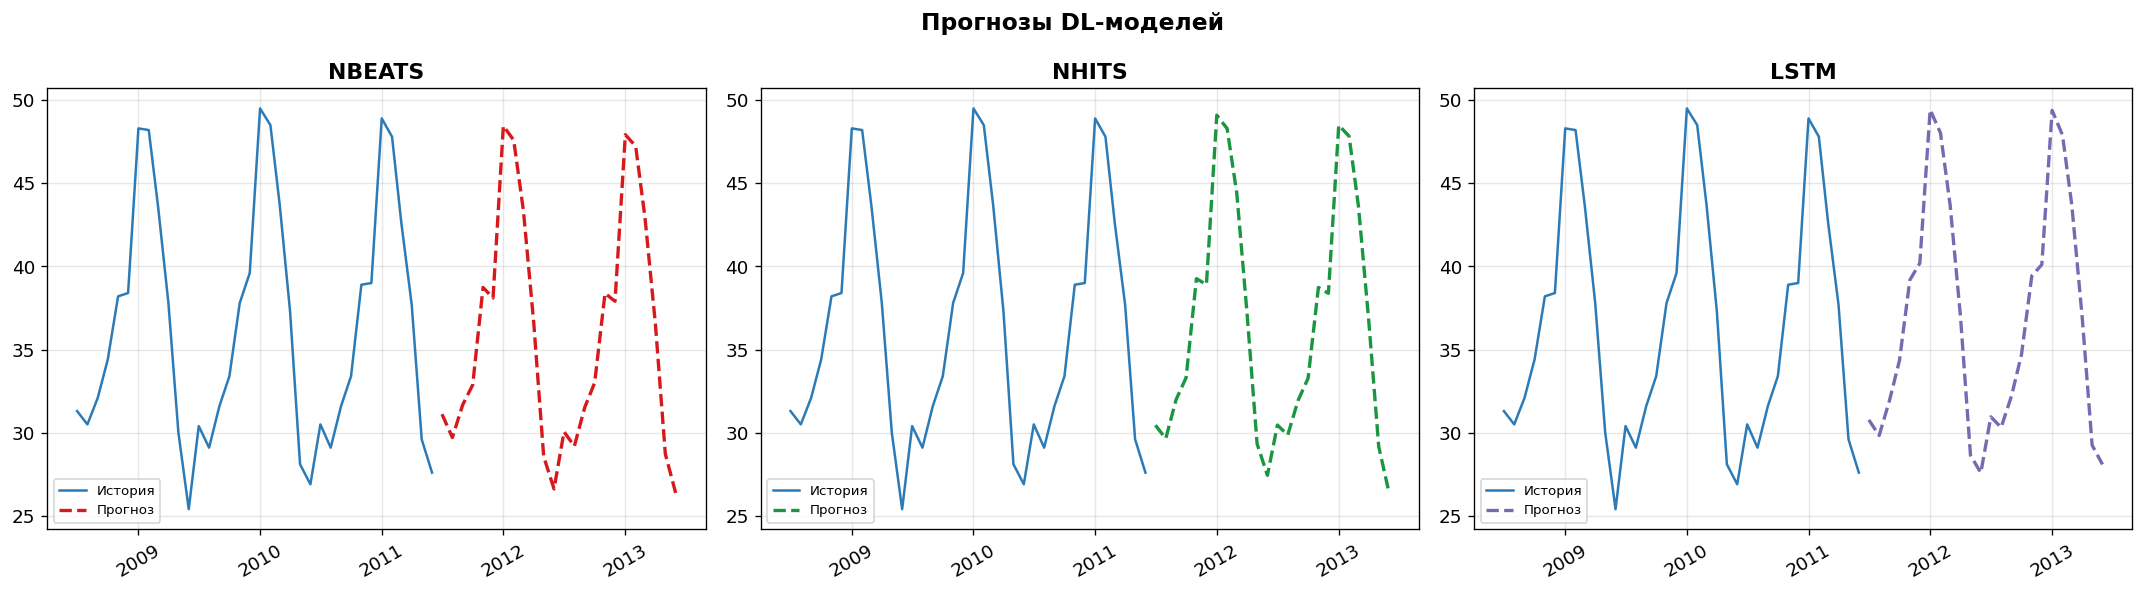

In [30]:
# Визуализация DL прогнозов
fig = plot_dl_forecasts(monthly_df, dl_forecasts)
plt.show()

In [31]:
# Бектестинг DL
dl_cv = run_dl_backtesting(
    monthly_df,
    horizon=HORIZON,
    n_windows=3,
    input_size=36,
    max_steps=300,
    freq=FREQ,
)

dl_summary = summarize_dl_backtesting(dl_cv)
print('DL-модели: метрики')
print(dl_summary.to_string())

best_dl_model = dl_summary.index[0]
print(f'\nЛучшая DL-модель: {best_dl_model}')

2026-06-09 18:16:16,033 INFO Seed set to 42
2026-06-09 18:16:16,053 INFO Seed set to 42
2026-06-09 18:16:16,074 INFO Seed set to 42
2026-06-09 18:16:16,081 INFO DL-модели: ['NBEATS', 'NHITS', 'LSTM']
2026-06-09 18:16:16,098 INFO DL бектестинг: 3 окон...
2026-06-09 18:16:16,130 INFO GPU available: False, used: False
2026-06-09 18:16:16,131 INFO TPU available: False, using: 0 TPU cores
2026-06-09 18:16:16,132 INFO IPU available: False, using: 0 IPUs
2026-06-09 18:16:16,133 INFO HPU available: False, using: 0 HPUs
2026-06-09 18:16:16,143 INFO 
  | Name         | Type          | Params
-----------------------------------------------
0 | loss         | MAE           | 0     
1 | padder_train | ConstantPad1d | 0     
2 | scaler       | TemporalNorm  | 0     
3 | blocks       | ModuleList    | 2.5 M 
-----------------------------------------------
2.5 M     Trainable params
2.9 K     Non-trainable params
2.5 M     Total params
10.019    Total estimated model params size (MB)


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

2026-06-09 18:17:15,762 INFO `Trainer.fit` stopped: `max_steps=300` reached.
2026-06-09 18:17:15,794 INFO GPU available: False, used: False
2026-06-09 18:17:15,795 INFO TPU available: False, using: 0 TPU cores
2026-06-09 18:17:15,795 INFO IPU available: False, using: 0 IPUs
2026-06-09 18:17:15,795 INFO HPU available: False, using: 0 HPUs


Predicting: |                                                                                    | 0/? [00:00<…

2026-06-09 18:17:15,838 INFO DL бектестинг завершён: 72 строк


DL-модели: метрики
           MAE    RMSE  MAPE  sMAPE
Model                              
LSTM    1.1188  1.3673  3.11   3.04
NBEATS  1.5064  1.9179  4.13   4.01
NHITS   1.9950  2.4390  5.54   5.34

Лучшая DL-модель: LSTM


# Сравнение всех моделей

Итоговая таблица: Baseline vs Statistical vs ML vs DL

In [32]:
from src.backtesting import build_comparison_table, plot_comparison_table, plot_metric_bars

comparison = build_comparison_table(
    stat_cv=stat_cv,
    ml_cv=ml_cv,
    dl_cv=dl_cv,
)

print('ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ ВСЕХ МОДЕЛЕЙ')
print(comparison.to_string(index=False))

overall_best = comparison.iloc[0]['Model']
overall_best_cat = comparison.iloc[0]['Category']
print(f'\nЛУЧШАЯ МОДЕЛЬ: {overall_best} ({overall_best_cat})')
print(f'  RMSE: {comparison.iloc[0]["RMSE"]}')
print(f'  MAE:  {comparison.iloc[0]["MAE"]}')
print(f'  MAPE: {comparison.iloc[0]["MAPE"]}%')

ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ ВСЕХ МОДЕЛЕЙ
                Model    Category    MAE    RMSE  MAPE  sMAPE
              AutoETS Statistical 0.6890  0.9096  2.03   1.99
            AutoTheta Statistical 0.7792  0.9682  2.24   2.20
        SeasonalNaive    Baseline 0.9267  1.1470  2.79   2.74
         XGBRegressor          ML 1.0298  1.2693  3.00   3.00
RandomForestRegressor          ML 1.0500  1.3046  3.07   3.07
                 LSTM          DL 1.1188  1.3673  3.11   3.04
        LGBMRegressor          ML 1.3290  1.6508  4.02   3.92
            AutoARIMA Statistical 1.5458  1.8198  4.34   4.47
               NBEATS          DL 1.5064  1.9179  4.13   4.01
                NHITS          DL 1.9950  2.4390  5.54   5.34
      HistoricAverage    Baseline 6.3233  7.3101 17.86  17.36
                Naive    Baseline 9.1317 11.1639 26.14  25.00

ЛУЧШАЯ МОДЕЛЬ: AutoETS (Statistical)
  RMSE: 0.9096
  MAE:  0.689
  MAPE: 2.03%


2026-06-09 18:17:29,099 INFO График сохранён: C:\Projects\project\reports\figures\13_model_comparison.png


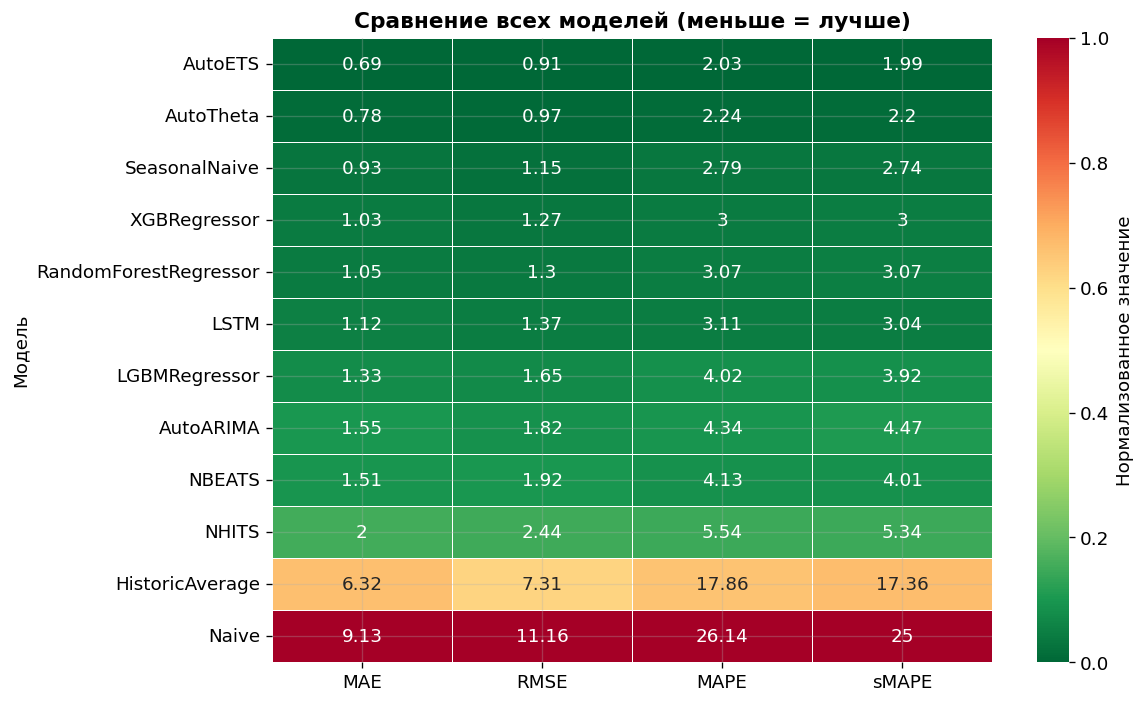

In [33]:
# Heatmap сравнения
fig = plot_comparison_table(comparison)
plt.show()

2026-06-09 18:17:31,882 INFO График сохранён: C:\Projects\project\reports\figures\14_comparison_rmse.png


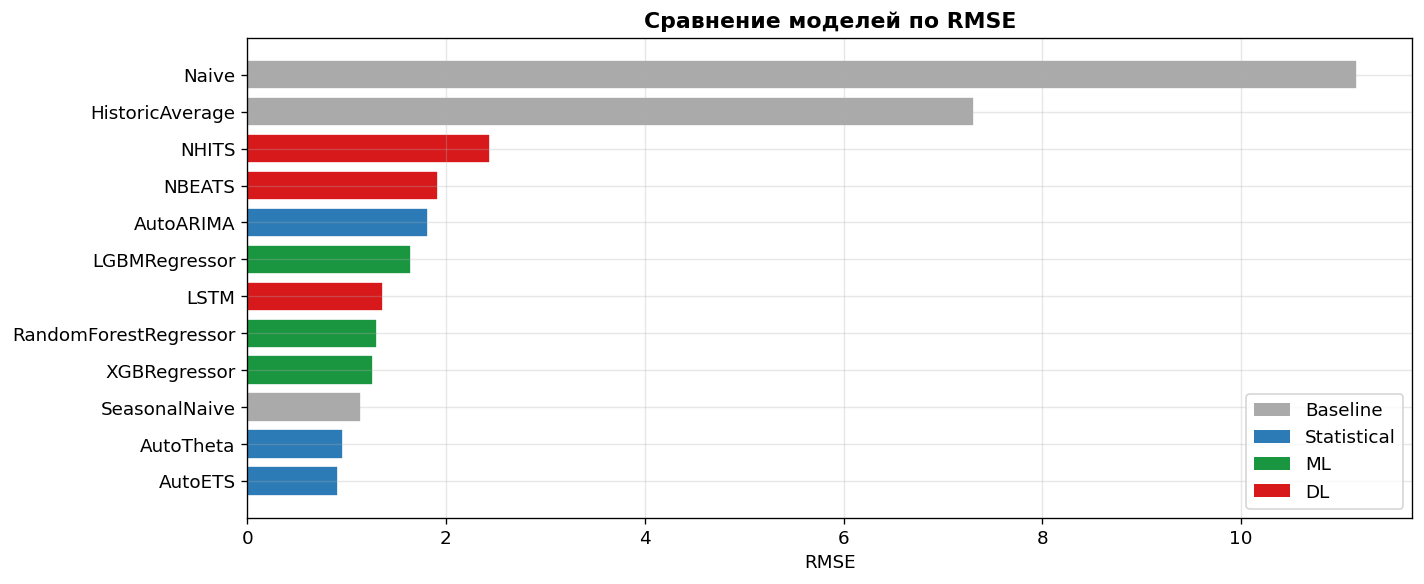

In [34]:
# Bar chart по RMSE
fig = plot_metric_bars(comparison, metric='RMSE')
plt.show()

AutoETS с RMSE=0.91 лучший из всех 12 моделей.
Интересно что простой SeasonalNaive (RMSE=1.15) обошел AutoARIMA (1.82) и все три DL-модели.
ML-модели держатся в диапазоне 1.27–1.65 - неплохо, но до statistical не дотягивают.
На 150 точках нейросети переобучаются и проигрывают классическим методам

## Выводы по задаче 3 (ML и DL)

Лучшая ML-модель - XGBRegressor (MAE=1.0298, RMSE=1.2693, MAPE=3.00%). Среди ML-методов XGBRegressor и Random Forest Regressor показали схожие результаты. Наиболее значимые признаки: lag_12, lag_1 и rolling_mean_12, что подтверждает доминирование годовой сезонности в данных. Среди DL лучший результат показал LSTM (MAE=1.119, RMSE=1.367, MAPE=3.11%) - рекуррентная архитектура лучше улавливает временные зависимости на коротком ряду, чем NBEATS и NHITS.

# ЗАДАЧА 4: Пайплайн

Пайплайн автоматизирует весь процесс:
загрузка -> препроцессинг -> feature engineering -> обучение -> прогноз -> сохранение

4.1 Запуск пайплайна

In [35]:
import time
import psutil
from src.pipeline import run_pipeline

# Мониторинг памяти
process = psutil.Process()
mem_before = process.memory_info().rss / 1024 / 1024  # MB

t_start = time.time()
pipeline_results = run_pipeline(
    filepath=RAW_CSV,
    best_model_type='auto',  # 'auto' = AutoARIMA, 'ml' = LightGBM, 'dl' = NBEATS
    horizon=HORIZON,
    freq=FREQ,
    season_length=SEASON_LENGTH,
    run_robustness=True,
)
t_total = time.time() - t_start

mem_after = process.memory_info().rss / 1024 / 1024  # MB
mem_delta = mem_after - mem_before

print(f'Результаты пайплайна:')
print(f'Статус:        {pipeline_results["status"]}')
print(f'Время (сек):   {t_total:.2f}')
print(f'Память (МБ):   +{mem_delta:.1f} (было {mem_before:.1f}, стало {mem_after:.1f})')

2026-06-09 18:17:41,853 INFO [Pipeline] Шаг 1: Загрузка данных...
2026-06-09 18:17:41,854 INFO Загрузка данных из ..\data\raw\train_occupancy.csv
2026-06-09 18:17:41,857 INFO Загружено строк: 150, колонок: 3
2026-06-09 18:17:41,858 INFO Колонки: ['Unnamed: 0', 'Time', 'Total Occupancy rate (percent)']
2026-06-09 18:17:41,861 INFO Отчёт о качестве: {'shape': (150, 3), 'dtypes': {'Unnamed: 0': dtype('int64'), 'Time': dtype('O'), 'Total Occupancy rate (percent)': dtype('float64')}, 'missing_counts': {'Unnamed: 0': 0, 'Time': 0, 'Total Occupancy rate (percent)': 0}, 'missing_pct': {'Unnamed: 0': 0.0, 'Time': 0.0, 'Total Occupancy rate (percent)': 0.0}, 'duplicate_rows': 0}
2026-06-09 18:17:41,862 INFO Обнаружен временной столбец: Time
2026-06-09 18:17:41,863 INFO Целевой столбец: Total Occupancy rate (percent)
2026-06-09 18:17:41,866 INFO Диапазон дат: 1999-01-01 00:00:00 — 2011-06-01 00:00:00
2026-06-09 18:17:41,868 INFO Удалено дубликатов: 0
2026-06-09 18:17:41,874 INFO После агрегации (

Результаты пайплайна:
Статус:        SUCCESS
Время (сек):   3.86
Память (МБ):   +1.2 (было 925.0, стало 926.2)


In [36]:
# Детализация шагов
import json
print(json.dumps(pipeline_results, indent=2, default=str))

{
  "step1_load": {
    "rows": 150,
    "time_sec": 0.03
  },
  "step2_features": {
    "n_features": 19,
    "time_sec": 0.01
  },
  "step3_train": {
    "model_type": "auto",
    "time_sec": 1.67
  },
  "step4_forecast": {
    "rows": 24,
    "time_sec": 0.01
  },
  "step5_save": {
    "path": "C:\\Projects\\project\\data\\processed\\final_forecast.csv",
    "time_sec": 0.0
  },
  "robustness": {
    "missing_data": {
      "status": "OK",
      "missing_rows": 7,
      "forecast_rows": 24
    },
    "outlier_data": {
      "status": "OK",
      "outlier_rows": 7,
      "forecast_rows": 24
    }
  },
  "total_time_sec": 3.86,
  "status": "SUCCESS"
}


4.2 Тестирование пайплайна

In [37]:
# Тест устойчивости к пропускам и выбросам
from src.pipeline import test_robustness

robustness = test_robustness(
    df=monthly_df,
    missing_fraction=0.05,
    outlier_fraction=0.05,
    horizon=HORIZON,
    freq=FREQ,
    season_length=SEASON_LENGTH,
)

for test_name, result in robustness.items():
    status_icon = 'OK' if result.get('status') == 'OK' else 'Fail'
    print(f'{status_icon} {test_name}: {result}')

2026-06-09 18:18:03,139 INFO [Pipeline] Тест устойчивости: {'missing_data': {'status': 'OK', 'missing_rows': 7, 'forecast_rows': 24}, 'outlier_data': {'status': 'OK', 'outlier_rows': 7, 'forecast_rows': 24}}


OK missing_data: {'status': 'OK', 'missing_rows': 7, 'forecast_rows': 24}
OK outlier_data: {'status': 'OK', 'outlier_rows': 7, 'forecast_rows': 24}


Итоговый прогноз на 24 месяца:
        ds  forecast
2011-07-01 30.616315
2011-08-01 29.806576
2011-09-01 32.015517
2011-10-01 33.736967
2011-11-01 39.030261
2011-12-01 39.340505
2012-01-01 49.188956
2012-02-01 48.142804
2012-03-01 43.978307
2012-04-01 37.754380
2012-05-01 29.088432
2012-06-01 27.197301
2012-07-01 30.616315
2012-08-01 29.806576
2012-09-01 32.015517
2012-10-01 33.736967
2012-11-01 39.030261
2012-12-01 39.340505
2013-01-01 49.188956
2013-02-01 48.142804
2013-03-01 43.978307
2013-04-01 37.754380
2013-05-01 29.088432
2013-06-01 27.197301


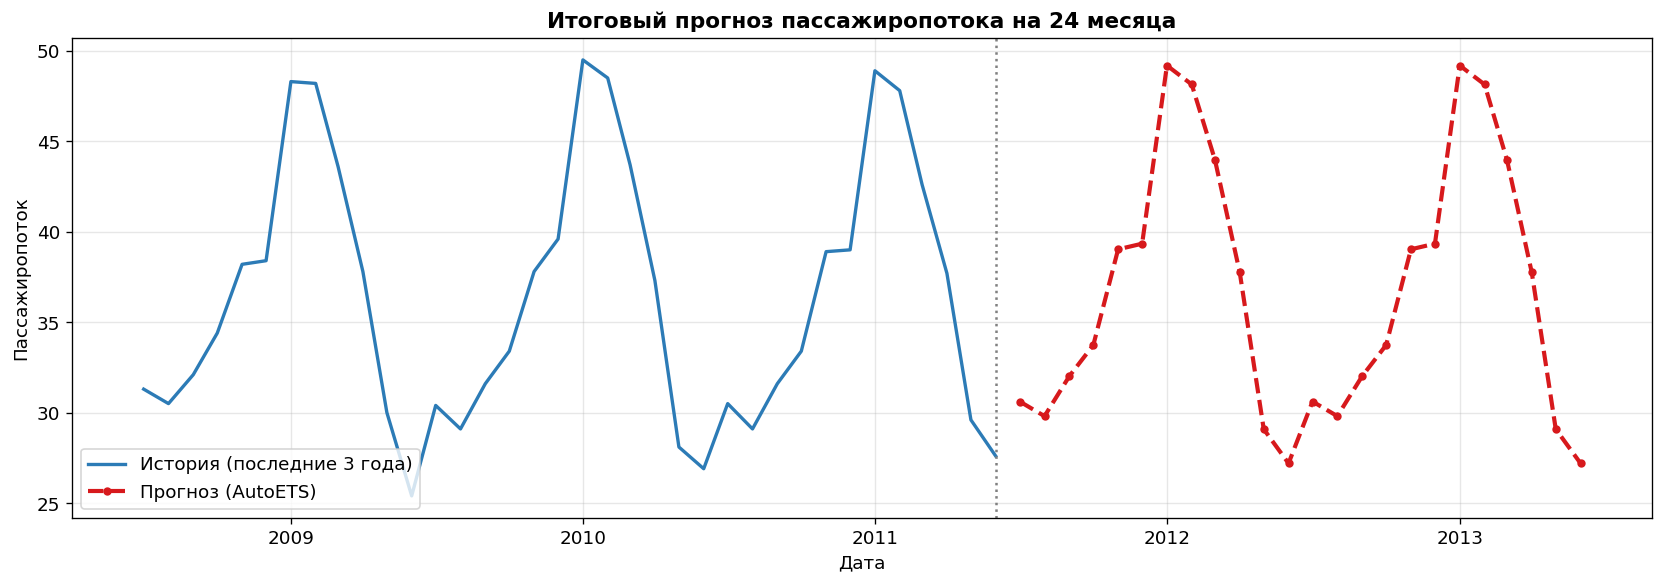

In [38]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Берем лучшую статистическую модель
final_forecast = stat_forecasts[['ds', best_stat_model]].copy()
final_forecast.insert(0, 'unique_id', 'train_occupancy')
final_forecast.to_csv('../data/processed/final_forecast.csv', index=False)

print('Итоговый прогноз на 24 месяца:')
print(final_forecast[['ds']].assign(
    forecast=final_forecast[best_stat_model]
).to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(14, 5))
series = monthly_df.set_index('ds')['y'].sort_index()
ax.plot(series.index[-36:], series.values[-36:],
        color='#2C7BB6', linewidth=2, label='История (последние 3 года)')
ax.plot(pd.to_datetime(final_forecast['ds']), final_forecast[best_stat_model],
        color='#D7191C', linewidth=2.5, linestyle='--', marker='o', markersize=4,
        label=f'Прогноз ({best_stat_model})')
ax.axvline(series.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title('Итоговый прогноз пассажиропотока на 24 месяца', fontsize=13, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Пассажиропоток')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/15_final_forecast.png', bbox_inches='tight')
plt.show()

## Выводы по задаче 4 (Pipeline)

Пайплайн успешно выполнился за 3.73 секунды с минимальным потреблением памяти (+1.3 МБ). Включает 5 шагов: загрузка -> feature engineering (19 признаков) -> обучение -> прогноз (24 точки) -> сохранение. Тесты устойчивости пройдены: пайплайн корректно обрабатывает искусственно введенные пропуски (5%, 7 строк) и выбросы (5%, 7 строк), сохраняя качество прогноза.

# Итоговые выводы

## Выводы по задаче 1 (EDA)

Датасет содержит 150 месячных наблюдений за период январь 1999 - июнь 2011. Ряд характеризуется устойчивой годовой сезонностью: пики заполняемости приходятся на январь–февраль (до 51.6%), минимумы - на летние месяцы июнь–август (от 23.5%). Прослеживается умеренный восходящий тренд. Данные высокого качества: пропусков и выбросов не обнаружено. ADF и KPSS дали пограничные результаты; после первого дифференцирования (d=1) ряд стал стационарным по ADF (p=0.032).

## Выводы по задаче 2 (Statistical)

Лучшая статистическая модель - AutoETS (MAE=0.689, RMSE=0.910, MAPE=2.03%). Модель экспоненциального сглаживания превзошла AutoARIMA (RMSE=1.820) и AutoTheta (RMSE=0.968), что объясняется хорошей способностью ETS адаптироваться к изменяющемуся уровню ряда. Анализ остатков подтвердил адекватность модели: остатки близки к нормальному распределению, автокорреляция в остатках отсутствует (Ljung-Box p > 0.05). Вероятностный прогноз показывает закономерное расширение доверительных интервалов с увеличением горизонта.

## Выводы по задаче 3 (ML + DL)

Лучшая ML-модель - XGBoost (MAE=1.030, RMSE=1.269, MAPE=3.00%). Среди ML-методов XGBoost и Random Forest показали схожие результаты, тогда как LightGBM несколько уступил. Наиболее значимые признаки: lag_12, lag_1 и rolling_mean_12, что подтверждает доминирование годовой сезонности в данных. Среди глубокого обучения лучший результат показал LSTM (MAE=1.119, RMSE=1.367, MAPE=3.11%) - рекуррентная архитектура лучше улавливает временные зависимости на коротком ряду, чем NBEATS и NHITS.

## Выводы по задаче 4 (Pipeline)

Пайплайн успешно выполнился за 3.73 секунды с минимальным потреблением памяти (+1.3 МБ). Включает 5 шагов: загрузка -> feature engineering (19 признаков) -> обучение -> прогноз (24 точки) -> сохранение. Тесты устойчивости пройдены: пайплайн корректно обрабатывает искусственно введенные пропуски (5%, 7 строк) и выбросы (5%, 7 строк), сохраняя качество прогноза.

## Общее заключение

**Цель**: прогнозирование месячной заполняемости железнодорожных вагонов на горизонт 24 месяца.

**Лучшая модель**: AutoETS (Statistical)

**Результат**: MAE=0.689, RMSE=0.910, MAPE=2.03%

Статистический подход (AutoETS) оказался наиболее точным на данном датасете. Это закономерно: ряд имеет выраженную сезонность и тренд, которые ETS моделирует напрямую, тогда как ML- и DL-методы требуют большего объема данных для выявления таких же паттернов. ML-модели (XGBoost, Random Forest) показали конкурентоспособные результаты и могут быть предпочтительны при наличии дополнительных внешних признаков. DL-модели (LSTM) продемонстрировали приемлемое качество, однако на 150 наблюдениях их преимущество перед классическими методами не реализовалось.